In [1]:
from helper_functions import *
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from matplotlib import pyplot as plt
from numpy.linalg import svd
from pcpca import PCPCA
from contrastive import CPCA
from os.path import join as pjoin
from scipy.io import mmread
from sklearn.decomposition import PCA
from cICA_functions import *
from ICA_code import *
from SPM import *
plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 14})

# Visualization

## Mice protein data

In [2]:
# Read in data
data = pd.read_excel('mouse_data/Data_Cortex_Nuclear.xlsx')

# Separate into background and foreground data
# background data is data from mice who did not receive shock therapy
# foreground data is from mice who did receive shock therapy

# Get names of proteins
protein_names = data.columns.values[1:78]

# Fill NAs
data = data.fillna(0)

# Background
Y_df = data[
    (data.Behavior == "C/S")
    & (data.Genotype == "Control")
    & (data.Treatment == "Saline")
]
Y = Y_df[protein_names].values
Y -= np.nanmean(Y, axis=0)
Y /= np.nanstd(Y, axis=0)



# Foreground
X_df = data[(data.Behavior == "S/C") & (data.Treatment == "Saline")]
X = X_df[protein_names].values
mean=np.nanmean(X, axis=0)
std=np.nanstd(X, axis=0)
X -= mean
X /= std

Z_1df=data[
    (data.Behavior == "S/C")
    & (data.Genotype == "Control")& (data.Treatment == "Saline")]
Z1 = Z_1df[protein_names].values
Z1 -= mean
Z1 /= std

Z_2df=data[
    (data.Behavior == "S/C")
    & (data.Genotype != "Control")& (data.Treatment == "Saline")]
Z2 = Z_2df[protein_names].values
Z2 -= mean
Z2 /= std

n,I = X.shape
m,_ = Y.shape
X=np.vstack((Z1,Z2))

from sklearn.decomposition import PCA

# 15 components explain 90% covariance
pca=PCA(n_components=15)
Y_pca=pca.fit(np.vstack((X,Y)))
print(np.cumsum(pca.explained_variance_ratio_))

Y_pca=pca.transform(Y)
Z1_pca=pca.transform(Z1)
Z2_pca=pca.transform(Z2)
X_pca=np.vstack((Z1_pca,Z2_pca))
k2_f,k4_f=cumulant_tensors(X_pca)
k2_b,k4_b=cumulant_tensors(Y_pca)

label=np.hstack((np.zeros(Z1_pca.shape[0]),np.ones(Z2_pca.shape[0])))

/Users/kexinwang/micromamba/envs/cs109a/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


[0.33875351 0.47301379 0.55444589 0.61736511 0.67233563 0.71487014
 0.75152446 0.78286761 0.80981964 0.8333142  0.84963109 0.86411082
 0.87609972 0.88651199 0.89588937]


In [3]:
# functions to compute silhouette score and plot graphs
def mice_silhouette(directions):
    pattern_1=directions[:,0]
    pattern_2=directions[:,1]
    cluster_1=np.vstack((pattern_1@Z1_pca.T,pattern_2@Z1_pca.T))
    cluster_2=np.vstack((pattern_1@Z2_pca.T,pattern_2@Z2_pca.T))
    label=np.hstack((np.zeros(cluster_1.shape[1]),np.ones(cluster_2.shape[1])))
    cluster=np.hstack((cluster_1,cluster_2))
    return silhouette_score(cluster.T,label)

def plot_graph_mice(directions,xlabel,ylabel,title,sil_score,name):
    fix,axs=plt.subplots(1,1,figsize=(6,6))
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@Y_pca.T,pattern_2@Y_pca.T,label='background')
    axs.scatter(pattern_1@Z1_pca.T,pattern_2@Z1_pca.T,label='Down symdrome')
    axs.scatter(pattern_1@Z2_pca.T,pattern_2@Z2_pca.T,label='no Down symdrome')
    axs.legend(frameon=False)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')


def mice_silhouette_whole_dataset(directions):
    pattern_1=directions[:,0]
    pattern_2=directions[:,1]
    cluster_1=np.vstack((pattern_1@Z1.T,pattern_2@Z1.T))
    cluster_2=np.vstack((pattern_1@Z2.T,pattern_2@Z2.T))
    label=np.hstack((np.zeros(cluster_1.shape[1]),np.ones(cluster_2.shape[1])))
    cluster=np.hstack((cluster_1,cluster_2))
    return silhouette_score(cluster.T,label)

def plot_graph_mice_wholedataset(directions,xlabel,ylabel,title,sil_score,name):
    fix,axs=plt.subplots(1,1,figsize=(6,6))
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@Y.T,pattern_2@Y.T,label='background')
    axs.scatter(pattern_1@Z1.T,pattern_2@Z1.T,label='Down symdrome')
    axs.scatter(pattern_1@Z2.T,pattern_2@Z2.T,label='no Down symdrome')
    axs.legend(frameon=False)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')


Text(0.5, 1.0, 'PCA on X silhouette score:0.063')

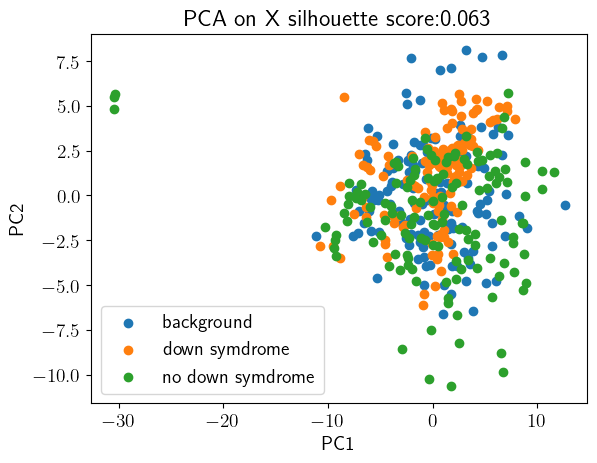

In [8]:
# PCA just on foreground does not work
label=np.vstack((np.zeros(Z1.shape[0]),np.ones(Z2.shape[0]))).reshape(-1)
pca=PCA(n_components=2)
X_top2=pca.fit_transform(X)
fig,axs=plt.subplots(1,1)
directions=pca.components_.T
pattern_1=directions[:,0].reshape(1,-1)
pattern_2=directions[:,1].reshape(1,-1)
axs.scatter(pattern_1@Y.T,pattern_2@Y.T,label='background')
axs.scatter(pattern_1@Z1.T,pattern_2@Z1.T,label='down symdrome')
axs.scatter(pattern_1@Z2.T,pattern_2@Z2.T,label='no down symdrome')
axs.legend()
axs.set_xlabel('PC1')
axs.set_ylabel('PC2')
sil_score=silhouette_score(X_top2,label)
axs.set_title('PCA on X'+' '+'silhouette score:'+f'{sil_score:0.3f}')

Text(0, 0.5, 'eigenvalue')

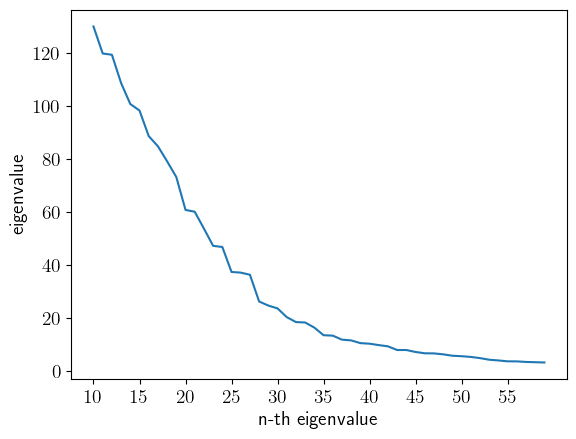

In [9]:
#cICA choices of r=27 based on eigenvalues of the background cumulant tensor flattened
I=k4_b.shape[0]
D,V=eig2(k4_b.reshape(I**2,I**2))
plt.plot(range(10,60),abs(D)[10:60])
plt.xticks(range(10,60,5))
plt.xlabel('n-th eigenvalue')
plt.ylabel('eigenvalue')

Text(0, 0.5, 'eigenvalue')

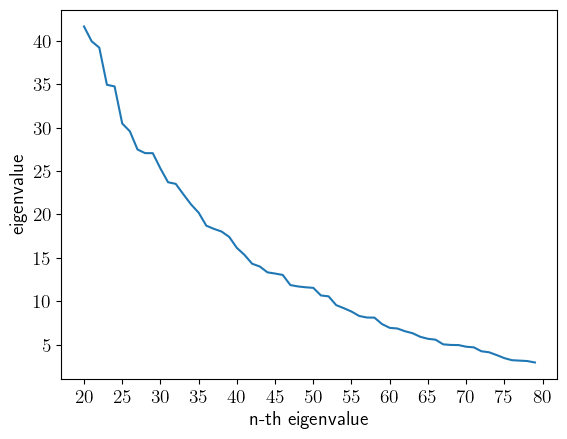

In [10]:
#cICA choices of r+\ell=53 based on eigenvalues of the foreground cumulant tensor flattened
I=k4_f.shape[0]
D,V=eig2(k4_f.reshape(I**2,I**2))
plt.plot(range(20,80),abs(D)[20:80])
plt.xticks(range(20,81,5))
plt.xlabel('n-th eigenvalue')
plt.ylabel('eigenvalue')

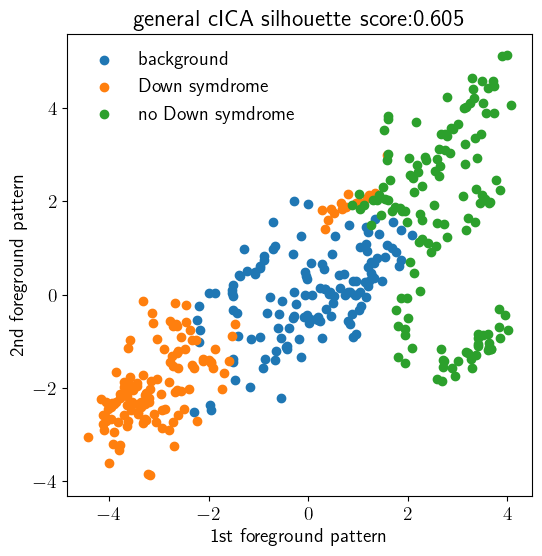

In [4]:
#cICA r=27 l=26 
np.random.seed(0)
a_s,b_s_sorted,cov_ratio=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,r=27,l=26)
plot_graph_mice(b_s_sorted[:,:2],'1st foreground pattern','2nd foreground pattern','general cICA',mice_silhouette(b_s_sorted[:,:2]),"mouse_cICA")

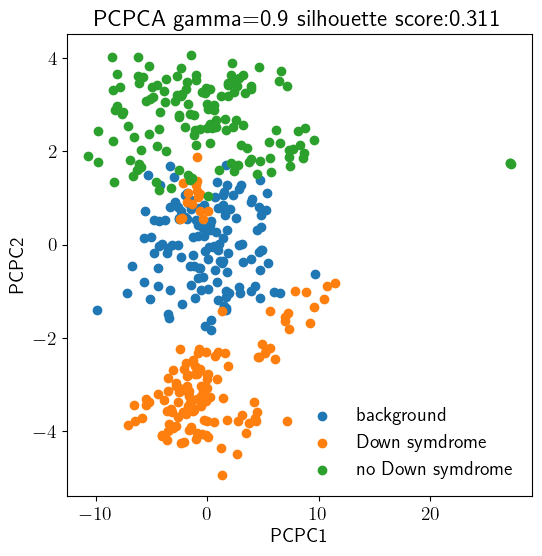

In [27]:
# choose gamma for PCPCA on whole datasets 
silhouette_score_list=[]
b_list=[]
n, m = X.shape[0], Y.shape[0]
for gamma in np.linspace(0,0.9,100):
    pcpca = PCPCA(gamma=n/m*gamma, n_components=2)
    X_reduced,Y_reduced=pcpca.fit_transform(X.T,Y.T)
    b=pcpca.W_mle
    silhouette_score_list.append(mice_silhouette_whole_dataset(b))
    b_list.append(b)
index=np.argmax(np.array(silhouette_score_list))
gamma=np.linspace(0,0.9,100)[index]
directions=b_list[index]
X_reduced,Y_reduced=pcpca.fit_transform(X.T,Y.T)
X_reduced = (X_reduced.T / X_reduced.T.std(0)).T

b=b_list[index]
b = b/np.linalg.norm(b,axis=0,keepdims=True)
plot_graph_mice_wholedataset(b,'PCPC1','PCPC2',f'PCPCA gamma={gamma}',mice_silhouette_whole_dataset(b),"pcpca")

[ 0.          0.61359073  7.05480231 53.36699231]


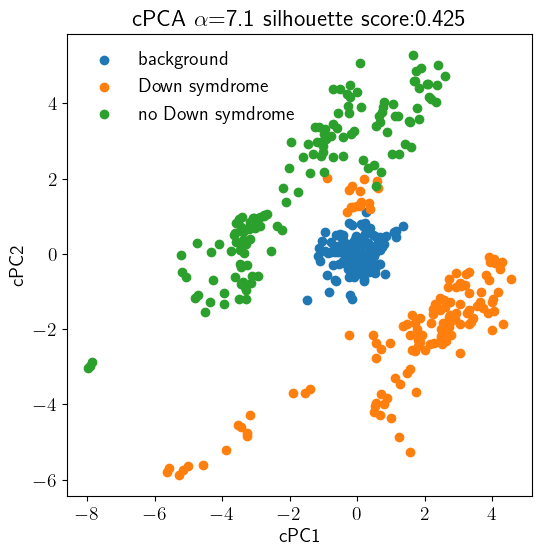

In [24]:
#CPCA whole dataset choose alpha
np.random.seed(0)
mdl=CPCA()
silhouette_score_list=[]
label=np.hstack((np.zeros(Z1.shape[0]),np.ones(Z2.shape[0])))
l,alphas=mdl.fit_transform(X,Y,active_labels=label,n_alphas=100,return_alphas=True,max_log_alpha=2)
print(alphas)
for array in l:
    silhouette_score_list.append(silhouette_score(array,label))
index=np.argmax(silhouette_score_list)
alpha=alphas[index]
D,V=np.linalg.eig(mdl.fg_cov-alpha*mdl.bg_cov)
eig_idx = np.argpartition(D, -2)[-2:]
b_cpca=V[:,eig_idx]
plot_graph_mice_wholedataset(b_cpca,'cPC1','cPC2',f'cPCA $\\alpha $={alpha:0.1f}',mice_silhouette_whole_dataset(b_cpca),"mouse_cPCA")
directions=b_cpca

1e-06


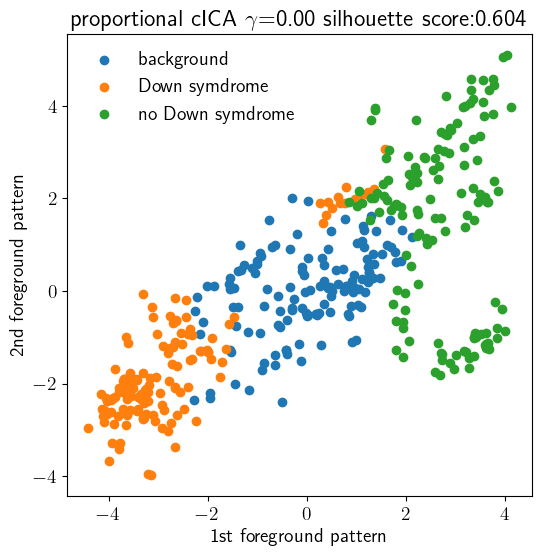

In [25]:
# hierachical tensor decomp of k4_f-gamma k4_b 
sil_score=[]
for gamma in np.logspace(-3,3,num=100): 
    gamma=gamma**2
    b_s_sorted,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,26)
    sil_score.append(mice_silhouette(b_s_sorted[:,:2]))
index=np.argmax(np.array(sil_score))
gamma=((np.logspace(-3,3,num=100))[index])**2
print(gamma)
b_s_sorted,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,26)
plot_graph_mice(b_s_sorted[:,:2],'1st foreground pattern','2nd foreground pattern',f'proportional cICA $\gamma$={gamma:0.2f}',mice_silhouette(b_s_sorted[:,:2]),"mouse_proportional_cICA")
directions=b_s_sorted[:,:2]

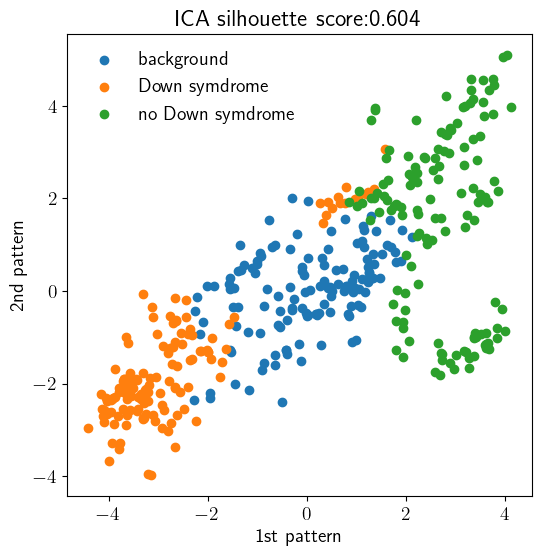

In [44]:
# ICA with HTD
np.random.seed(0)
a_s,b_s_sorted,cov_ratio=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,r=0,l=26+27)
plot_graph_mice(b_s_sorted[:,:2],'1st pattern','2nd pattern','ICA',mice_silhouette(b_s_sorted[:,:2]),"mouse_ICA")


## Single-cell RNA data

In [ ]:
# # data downloaded from https://www.10xgenomics.com/datasets/frozen-bmm-cs-healthy-control-2-1-standard-1-1-0
# fnames = ['293t',           #0
#           'aml027_post',    #1
#           'aml027_pre',     #2
#           'aml035_post',    #3
#           'aml035_pre',     #4
#           'b',              #5
#           'bmmc_healthy_1', #6
#           'bmmc_healthy_2', #7
#          ] 
# # replace with your own data directory
# DATA_DIR = 'single_cell_RNA_data_files/'
# N_GENES = 500


# def get_data_df(subdata_dir):
#     data = mmread(pjoin(DATA_DIR, subdata_dir, "hg19/matrix.mtx")).toarray()
#     data = np.log(data + 1)
#     genes = pd.read_table(pjoin(DATA_DIR, subdata_dir, "hg19/genes.tsv"), header=None)
#     barcodes = pd.read_table(
#         pjoin(DATA_DIR, subdata_dir, "hg19/barcodes.tsv"), header=None
#     )
#     data_df = pd.DataFrame(
#         data, index=genes.iloc[:, 0].values, columns=barcodes.iloc[:, 0].values
#     )

#     data_df = data_df.iloc[:, np.sum(data_df.values, axis=0) != 0]
#     data_df = data_df.iloc[np.sum(data_df.values, axis=1) != 0, :]
#     return data_df.transpose()


# ## Load all data
# pretransplant1 = get_data_df("aml027_pre")
# posttransplant1 = get_data_df("aml027_post")
# pretransplant2 = get_data_df("aml035_pre")
# posttransplant2 = get_data_df("aml035_post")

# healthy1 = get_data_df("bmmc_healthy_1")
# healthy2 = get_data_df("bmmc_healthy_2")

# shared_genes = pretransplant1.columns.values
# for curr_df in [posttransplant1, pretransplant2, posttransplant2, healthy1, healthy2]:
#     shared_genes = np.intersect1d(shared_genes, curr_df.columns.values)

# stacked_df = pretransplant1[shared_genes]
# for curr_df in [
#     posttransplant1,
#     pretransplant2,
#     posttransplant2,
# ]:  # , healthy1, healthy2]:
#     stacked_df = pd.concat([stacked_df, curr_df[shared_genes]], axis=0)
# print("Total of {} cells and {} genes".format(stacked_df.shape[0], stacked_df.shape[1]))

# gene_means = np.mean(stacked_df.values, axis=0)
# gene_vars = np.var(stacked_df.values, axis=0)
# gene_dispersions = gene_vars / gene_means
# top_idx = np.argsort(-gene_dispersions)[:N_GENES]
# top_genes = stacked_df.columns.values[top_idx]

# print("Saving {} genes".format(top_genes.shape[0]))

# pretransplant1[top_genes].to_csv(pjoin(DATA_DIR, "RNA_clean", "pretransplant1.csv"))
# posttransplant1[top_genes].to_csv(pjoin(DATA_DIR, "RNA_clean", "posttransplant1.csv"))

# pretransplant2[top_genes].to_csv(pjoin(DATA_DIR, "RNA_clean", "pretransplant2.csv"))
# posttransplant2[top_genes].to_csv(pjoin(DATA_DIR, "RNA_clean", "posttransplant2.csv"))

# healthy1[top_genes].to_csv(pjoin(DATA_DIR, "RNA_clean", "healthy1.csv"))
# healthy2[top_genes].to_csv(pjoin(DATA_DIR, "RNA_clean", "healthy2.csv"))

Total of 12399 cells and 12079 genes
Saving 500 genes


In [5]:
# Background is made up of healthy cells

#  replace with your own data directory
DATA_DIR = ''
pretransplant2 = pd.read_csv(pjoin(DATA_DIR, "RNA_clean", "pretransplant2.csv"), index_col=0)
pretransplant1= pd.read_csv(pjoin(DATA_DIR, "RNA_clean", "pretransplant1.csv"), index_col=0)
posttransplant2 = pd.read_csv(pjoin(DATA_DIR, "RNA_clean", "posttransplant2.csv"), index_col=0)
posttransplant1=pd.read_csv(pjoin(DATA_DIR, "RNA_clean", "posttransplant1.csv"), index_col=0)

healthy1 = pd.read_csv(pjoin(DATA_DIR, "RNA_clean", "healthy1.csv"), index_col=0)
healthy2= pd.read_csv(pjoin(DATA_DIR, "RNA_clean", "healthy2.csv"), index_col=0)
Y = pd.concat([healthy1, healthy2], axis=0).values

X = pd.concat([pretransplant2,pretransplant1, posttransplant2,posttransplant1], axis=0).values
X_pre= pd.concat([pretransplant2, pretransplant1], axis=0).values
X_post= pd.concat([posttransplant2,posttransplant1], axis=0).values

# Standardize
Y -= Y.mean(0)
Y /= Y.std(0)
a=X.mean(0)
b=X.std(0)
X -= a
X /= b
X_pre-=a
X_pre/=b
X_post-=a
X_post/=b

n, m = X.shape[1], Y.shape[1]

pca=PCA(n_components=30)
pca.fit(np.vstack((X,Y)))
print(np.cumsum(pca.explained_variance_ratio_))

X_pca_pre=pca.transform(X_pre)
X_pca_post=pca.transform(X_post)
Y_pca=pca.transform(Y)
X_pca=pca.transform(X)
X_pca=np.vstack((X_pca_pre,X_pca_post))

label=np.hstack((np.zeros(X_pca_pre.shape[0]),np.ones(X_pca_post.shape[0])))

# k2_f,k4_f=cumulant_tensors(X_pca)
# k2_b,k4_b=cumulant_tensors(Y_pca)
k2_b=np.load('RNA_clean/k2_b.npy')
k2_f=np.load('RNA_clean/k2_f.npy')
k4_b=np.load('RNA_clean/k4_b.npy')
k4_f=np.load('RNA_clean/k4_f.npy')

[0.19160671 0.29613218 0.33393818 0.36200888 0.38282322 0.40232312
 0.41945093 0.43330493 0.44555631 0.45596845 0.46459935 0.47239533
 0.47941659 0.48571725 0.49194182 0.4971536  0.50222036 0.50705607
 0.51157859 0.51589773 0.52006455 0.52402456 0.52755097 0.53105643
 0.53448322 0.53786426 0.54107268 0.54419389 0.54714367 0.54996425]


In [6]:
# functions to plot graphs

def plot_graph_RNA(directions,xlabel,ylabel,title,sil_score
                   ):
    fig,axs=plt.subplots(1,1,figsize=(6,6))
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@X_pca_post.T,pattern_2@X_pca_post.T,label='post-transplant',s=0.8)
    axs.scatter(pattern_1@X_pca_pre.T,pattern_2@X_pca_pre.T,label='pre-transplant',s=0.8)  
    axs.legend(frameon=False)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')
   

def plot_graph_RNA_2(directions,xlabel,ylabel,title,sil_score
                     ):
    fig,axs=plt.subplots(1,1,figsize=(6,6))
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@X_pca_pre.T,pattern_2@X_pca_pre.T,label='pre-transplant',s=0.8)
    axs.scatter(pattern_1@X_pca_post.T,pattern_2@X_pca_post.T,label='post-transplant',s=0.8)
    axs.legend(frameon=False)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')

def plot_graph_RNA_wholedataset(directions,xlabel,ylabel,title,sil_score
                                ):
    fig,axs=plt.subplots(1,1,figsize=(6,6))
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@X_post.T,pattern_2@X_post.T,label='post-transplant',s=0.8)
    axs.scatter(pattern_1@X_pre.T,pattern_2@X_pre.T,label='pre-transplant',s=0.8)
    axs.legend(frameon=False)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)

    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')


def plot_graph_RNA_2_wholedataset(directions,xlabel,ylabel,title,sil_score                          ):
    fig,axs=plt.subplots(1,1,figsize=(6,6))
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@X_pre.T,pattern_2@X_pre.T,label='pre-transplant',s=0.8)
    axs.scatter(pattern_1@X_post.T,pattern_2@X_post.T,label='post-transplant',s=0.8)
    axs.legend(frameon=False)
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')


def RNA_silhouette(directions):
    pattern_1=directions[:,0]
    pattern_2=directions[:,1]
    cluster_1=np.vstack((pattern_1@X_pca_pre.T,pattern_2@X_pca_pre.T))
    cluster_2=np.vstack((pattern_1@X_pca_post.T,pattern_2@X_pca_post.T))
    cluster_label=np.hstack((np.zeros(cluster_1.shape[1]),np.ones(cluster_2.shape[1])))
    cluster=np.hstack((cluster_1,cluster_2))
    return silhouette_score(cluster.T,cluster_label)



def RNA_silhouette_wholedataset(directions):
    pattern_1=directions[:,0]
    pattern_2=directions[:,1]
    cluster_1=np.vstack((pattern_1@X_pre.T,pattern_2@X_pre.T))
    cluster_2=np.vstack((pattern_1@X_post.T,pattern_2@X_post.T))
    cluster_label=np.hstack((np.zeros(cluster_1.shape[1]),np.ones(cluster_2.shape[1])))
    cluster=np.hstack((cluster_1,cluster_2))
    return silhouette_score(cluster.T,cluster_label)

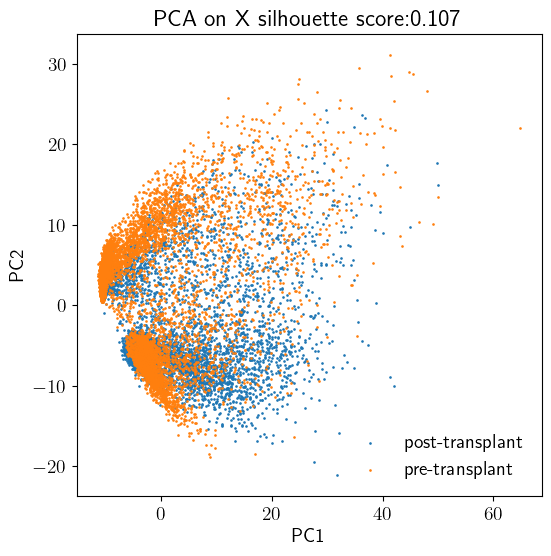

In [38]:
# PCA on foreground does not work
pca=PCA(n_components=2)
X_top2_RNA=pca.fit_transform(X)
directions=pca.components_.T
pattern_1=directions[:,0].reshape(1,-1)
pattern_2=directions[:,1].reshape(1,-1)

sil_score=RNA_silhouette_wholedataset(directions)
plot_graph_RNA_wholedataset(directions,'PC1','PC2','PCA on X',sil_score)

Text(0, 0.5, 'eigenvalue')

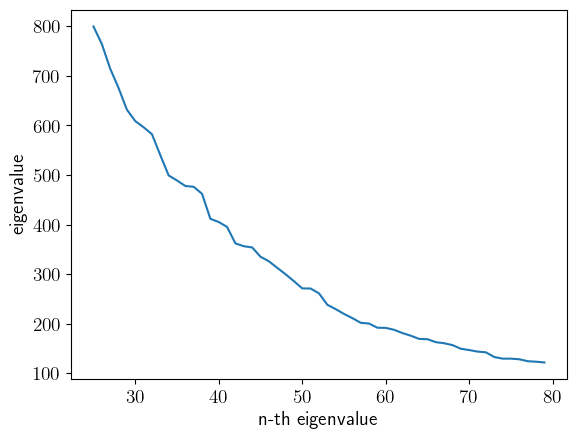

In [41]:
#cICA choices of r = 53
I=k4_b.shape[0]
D,V=eig2(k4_b.reshape(I**2,I**2))
plt.plot(range(25,80),abs(D)[25:80])
plt.xlabel('n-th eigenvalue')
plt.ylabel('eigenvalue')

Text(0, 0.5, 'eigenvalue')

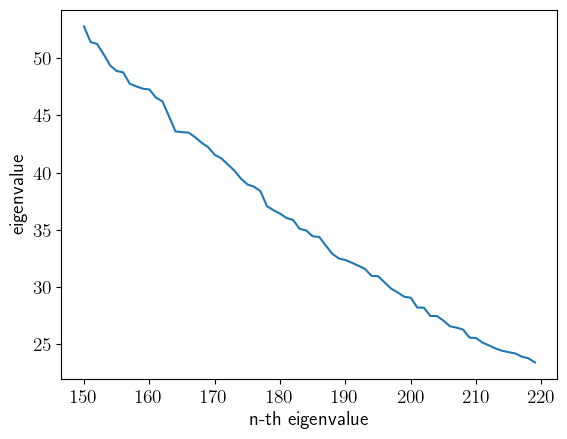

In [13]:
#cICA choice of r+\ell = 53+63
I=k4_f.shape[0]
D,V=eig2(k4_f.reshape(I**2,I**2))
plt.plot(range(150,220),abs(D)[150:220])
plt.xlabel('n-th eigenvalue')
plt.ylabel('eigenvalue')


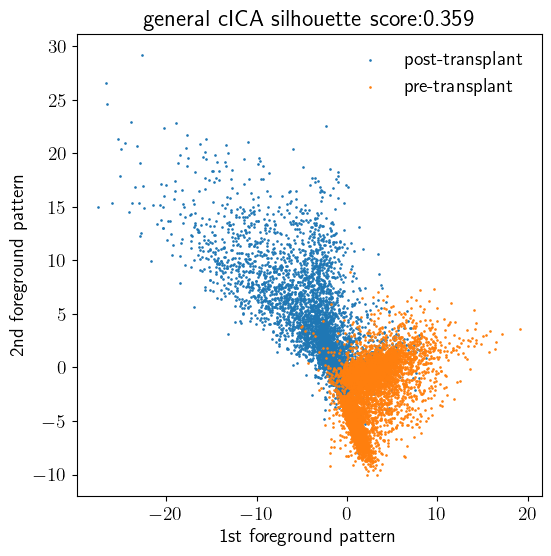

In [17]:
#cICA 
np.random.seed(0)
a_s,b_s_sorted,cov_ratio=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,r=53,l=116)
plot_graph_RNA(b_s_sorted[:,[0,1]],'1st foreground pattern','2nd foreground pattern','general cICA',RNA_silhouette(b_s_sorted[:,[0,1]]))

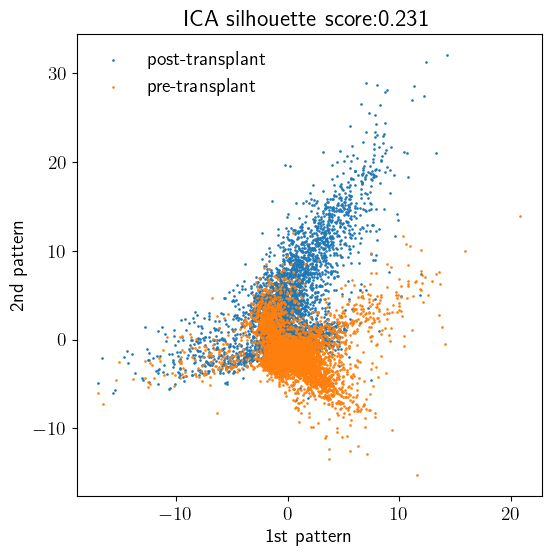

In [11]:
#ICA r=53+63 does not work
np.random.seed(0)
_,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,r=0,l=53+116)
plot_graph_RNA(b_s_sorted[:,[0,1]],'1st pattern','2nd pattern','ICA',RNA_silhouette(b_s_sorted[:,[0,1]]))

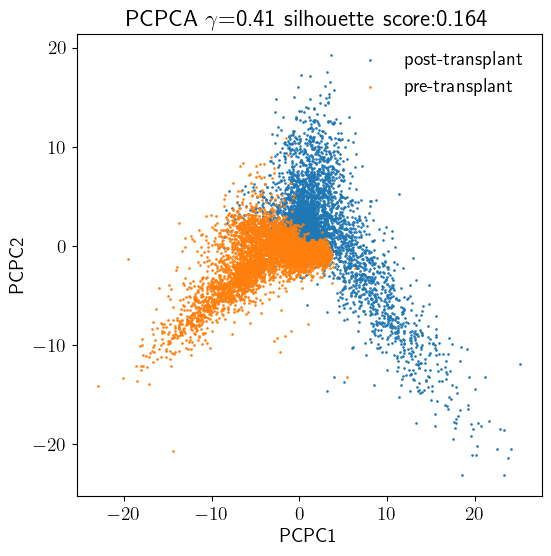

In [18]:
#PCPCA on whole dataset choose gamma
silhouette_score_list=[]
b_list=[]
n= X.shape[0]
m=Y.shape[0]
for gamma in np.linspace(0,0.9,100):
    pcpca = PCPCA(gamma=n/m*gamma, n_components=4)
    pcpca.fit(X.T,Y.T)
    b=pcpca.W_mle/np.linalg.norm(pcpca.W_mle,axis=0,keepdims=True)
    silhouette_score_list.append(RNA_silhouette_wholedataset(b[:,[2,3]]))
    b_list.append(b)
index=np.argmax(np.array(silhouette_score_list))
gamma=np.linspace(0,0.9,100)[index]
directions=b_list[index]

b = directions/np.linalg.norm(directions,axis=0,keepdims=True)
plot_graph_RNA_wholedataset(b[:,[2,3]],'PCPC1','PCPC2',f'PCPCA $\gamma$={gamma:0.2f}',silhouette_score_list[index])

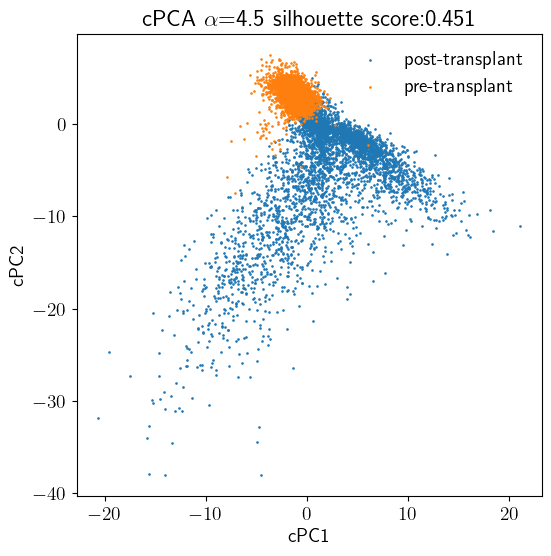

In [20]:
#CPCA on whole dataset
mdl=CPCA()
silhouette_score_list=[]
l,alphas=mdl.fit_transform(X,Y,active_labels=label,n_alphas=100,return_alphas=True,max_log_alpha=3)
label=np.hstack((np.zeros(X_pre.shape[0]),np.ones(X_post.shape[0])))
for array in l:
    silhouette_score_list.append(silhouette_score(array,label))
index=np.argmax(np.array(silhouette_score_list))
alpha=alphas[index]
D,V=np.linalg.eig(mdl.fg_cov-alpha*mdl.bg_cov)
eig_idx = np.argpartition(D, -2)[-2:] 
b_cpca=V[:,eig_idx]
plot_graph_RNA_wholedataset(b_cpca,'cPC1','cPC2',f'cPCA $\\alpha$={alpha:0.1f}',silhouette_score_list[index])
directions=b_cpca


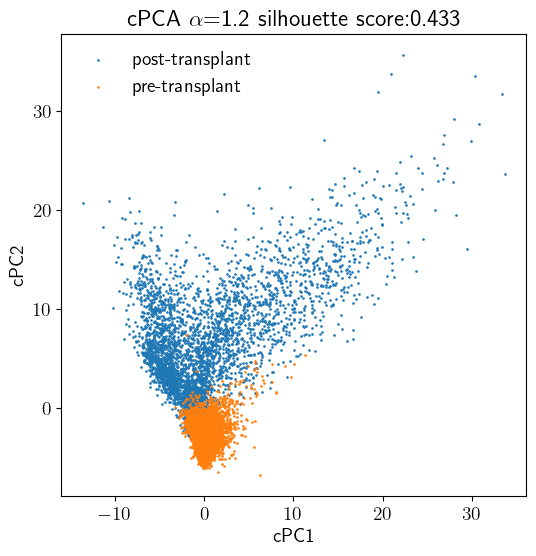

In [21]:
#cPCA on PCA projected dataset
mdl=CPCA()
silhouette_score_list=[]
l,alphas=mdl.fit_transform(X_pca,Y_pca,active_labels=label,n_alphas=100,return_alphas=True,max_log_alpha=2)
label=np.hstack((np.zeros(X_pre.shape[0]),np.ones(X_post.shape[0])))
for array in l:
    silhouette_score_list.append(silhouette_score(array,label))
index=np.argmax(np.array(silhouette_score_list))
alpha=alphas[index]
D,V=np.linalg.eig(mdl.fg_cov-alpha*mdl.bg_cov)
eig_idx = np.argpartition(D, -2)[-2:]
b_cpca=V[:,eig_idx]
plot_graph_RNA(b_cpca,'cPC1','cPC2',f'cPCA $\\alpha$={alpha:0.1f}',silhouette_score_list[index])
directions=b_cpca

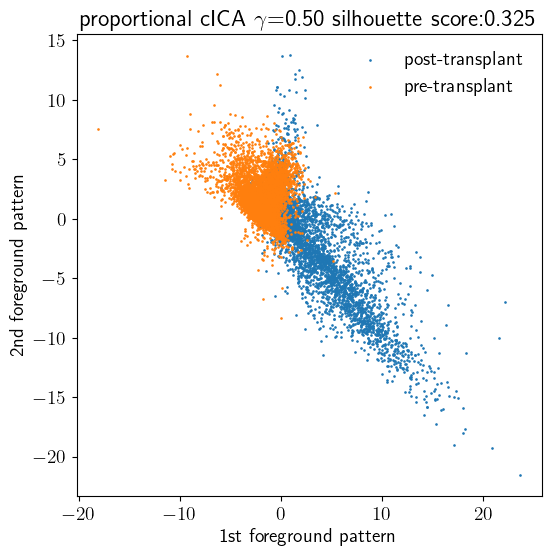

In [ ]:
# hierachical tensor decomp of k4_f-gamma k4_b
np.random.seed(0)
sil_score=[]
for gamma in np.logspace(-3,3,num=100):
    gamma=gamma**2 
    b_s_sorted,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,63)
    sil_score.append(RNA_silhouette(b_s_sorted[:,:2]))
index=np.argmax(np.array(sil_score))
gamma=(np.logspace(-3,3,num=100)[index])**2
b_s_sorted,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,63)
plot_graph_RNA(b_s_sorted[:,:2],'1st foreground pattern','2nd foreground pattern',f'proportional cICA $\gamma$={gamma:0.2f}',RNA_silhouette(b_s_sorted[:,:2]))

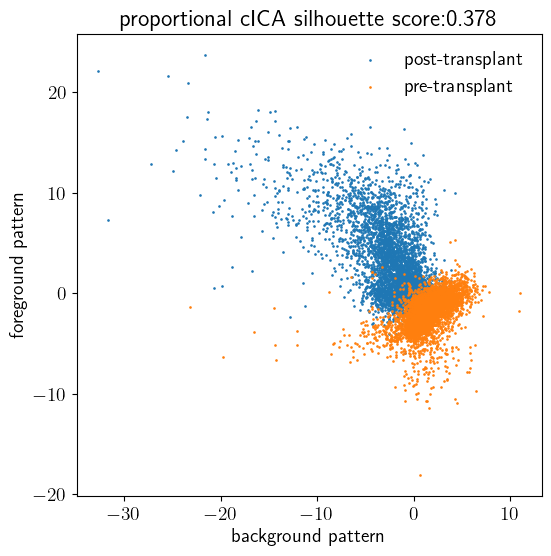

In [21]:
# find best a cICA and project the dataset on best a, best b
def ratio(a):
    return np.linalg.norm(a@k2_f@a.T)/np.linalg.norm(a@k2_b@a.T)
ratio_list = []
for a in a_s.T:
    ratio_list.append(ratio(a))
index = np.argmax(ratio_list)

a= a_s[:,index]
a_projected = a - np.sum(a*b_s_sorted[:,0])*b_s_sorted[:,0]
a_projected = a_projected/np.linalg.norm(a_projected)
pattern = np.vstack((a_projected,b_s_sorted[:,0])).T
RNA_silhouette(pattern)
plot_graph_RNA(pattern,'background pattern','foreground pattern','proportional cICA',RNA_silhouette(pattern))

## MNIST  discrete strength

In [ ]:
## background 50% grass, 50% cloud, foreground 80% grass, 20% cloud
## grass images are downloaded from imagenet with id n12102133
## cloud images are downloaded from imagenet with id n09247410

# grass_IMAGE_PATH = 'n12102133/' #Replace with your own path to downloaded images
# cloud_IMAGE_PATH = 'n09247410/' #Replace with your own path to downloaded images



# import numpy as np
# import keras
# from keras.datasets import mnist
# (X_train, y_train), (X_test, y_test) = mnist.load_data()
# index_0=np.where(y_train==0)[0]
# index_1=np.where(y_train == 1)[0]
# foreground=np.zeros(shape = (10000,28,28))
# foreground[:2500,:,:]=X_train[index_0][:2500]
# foreground[2500:5000,:,:]=X_train[index_1][:2500]
# foreground[5000:7500,:,:]=X_train[index_0][2500:5000]+X_train[index_1][2500:5000]
# foreground[5000:7500,:,:][foreground[5000:7500,:,:]>255]=255

# # 0 means image 0, 1 means image 1, 
# target_labels = np.sort(np.repeat([0, 1, 2, 3], 2500))


# from PIL import Image
# from resizeimage import resizeimage
# import os
        
# grass_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
# num=0
# for filename in os.listdir(grass_IMAGE_PATH):
#     num+=1
#     if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
#         try:
#             im = Image.open(os.path.join(grass_IMAGE_PATH,filename))
#             im = im.convert(mode="L") #convert to grayscale

#             im = resizeimage.resize_crop(im,[100,100]) #resize and crop each picture to be 100px by 100px
#             grass_images.append(np.reshape(im, [10000])) 
#         except Exception as e:
#             pass #print(e)
            
# grass_images=np.asarray(grass_images,dtype=float)
# grass_images/=255 #rescale to be 0-1
# print("Array of grass images:",grass_images.shape)


# cloud_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
# num=0
# for filename in os.listdir(cloud_IMAGE_PATH):
#     num+=1
#     if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
#         try:
#             im = Image.open(os.path.join(cloud_IMAGE_PATH,filename))
#             im = im.convert(mode="L") #convert to grayscale

#             im = resizeimage.resize_crop(im,[100,100]) #resize and crop each picture to be 100px by 100px
#             cloud_images.append(np.reshape(im, [10000])) 
#         except Exception as e:
#             pass #print(e)
    
# cloud_images=np.asarray(cloud_images,dtype=float)
# cloud_images/=255 #rescale to be 0-1
# print("Array of cloud images:",cloud_images.shape)
# # Corrupt the MNIST digits with the grass and cloud images 
# from tqdm import tqdm

# np.random.seed(0)  # for reproducibility

# grass_rand_indices = np.random.permutation(
#     grass_images.shape[0]
# )  # just shuffles the indices
# grass_split = int(len(grass_rand_indices) / 2)
# target_grass_indices = grass_rand_indices[
#     0:grass_split
# ]  # choose the first half of images to be superimposed on target
# background_grass_indices = grass_rand_indices[
#     grass_split:
# ]  # choose the second half of images to be background dataset



# cloud_rand_indices = np.random.permutation(
#     cloud_images.shape[0]
# )  # just shuffles the indices
# cloud_split = int(len(cloud_rand_indices) / 2)
# target_cloud_indices = cloud_rand_indices[
#     0:cloud_split
# ]  # choose the first half of images to be superimposed on target
# background_cloud_indices = cloud_rand_indices[
#     cloud_split:
# ]  # choose the second half of images to be background dataset

# target = np.zeros((foreground.shape[0],28**2))
# background = np.zeros((foreground.shape[0],28**2))


# permuted_index = np.random.permutation(10000)
# print("Corrupting MNIST with grass and cloud...")
# grass_cloud_foreground = np.zeros((foreground.shape[0],28**2))
# for i in range(int(target.shape[0]/10*8)):
#     idx = np.random.choice(target_grass_indices) # randomly pick a image 
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     superimposed_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784]) 
#     grass_cloud_foreground[i]=superimposed_patch
#     # foregroundreshaped=foreground[i].reshape(1,-1)
#     # target[permuted_index[i]] = 0.25* foregroundreshaped/255+ superimposed_patch

# for i in range(int(target.shape[0]/10*8),target.shape[0]):
#     idx = np.random.choice(target_cloud_indices) # randomly pick a image
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     superimposed_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
#     grass_cloud_foreground[i]=superimposed_patch
#     # foregroundreshaped=foreground[i].reshape(1,-1)
#     # target[permuted_index[i]] = 0.25* foregroundreshaped/255+ superimposed_patch

# for i in range(10000):
#     foregroundreshaped=foreground[i].reshape(1,-1)
#     target[i] = 0.35* foregroundreshaped/255+ grass_cloud_foreground[permuted_index[i]]

# for i in range(target.shape[0]//2):
#     idx = np.random.choice(background_grass_indices) # randomly pick a image 
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     background_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])    
#     background[permuted_index[i]] = background_patch

#     idx = np.random.choice(background_cloud_indices) # randomly pick a image
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     background_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
#     background[permuted_index[i+target.shape[0]//2]] = background_patch

      

# np.save("./corrupted_mnist_grass_cloud/X_independent_0_1_clearer.npy", target)
# np.save("./corrupted_mnist_grass_cloud/Y_independent_0_1_clearer.npy", background)
# np.save("./corrupted_mnist_grass_cloud/label_independent_0_1_clearer.npy", target_labels)

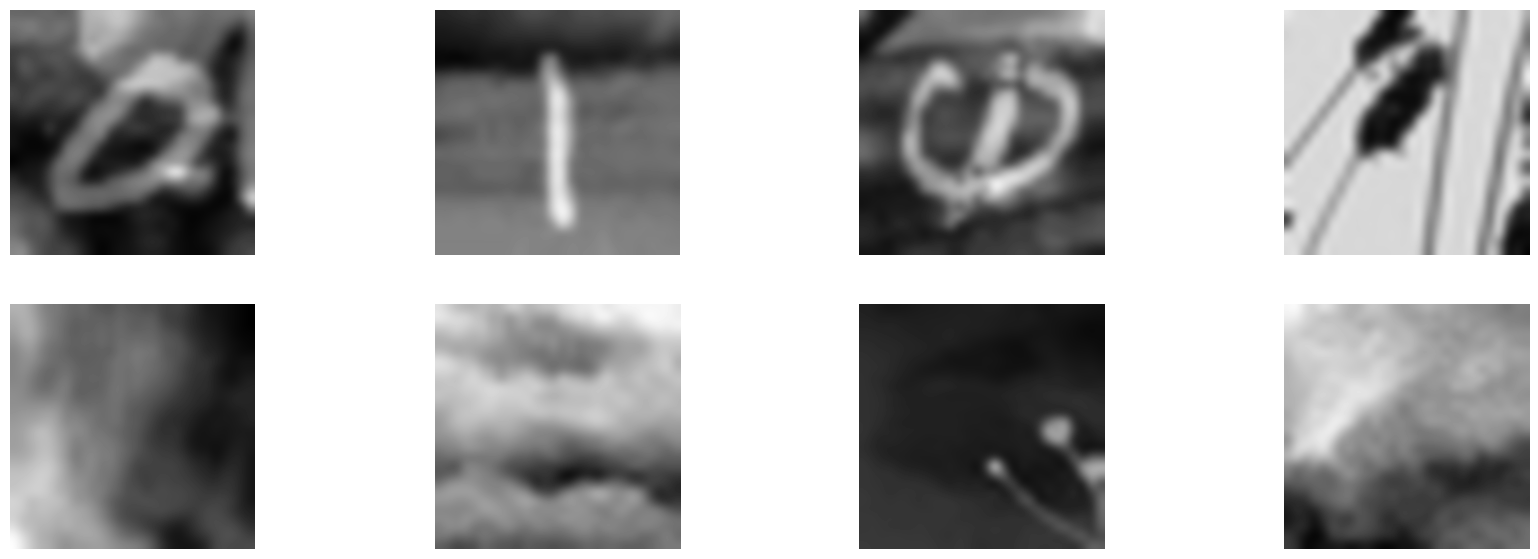

In [4]:
X=np.load("./corrupted_mnist_grass_cloud/X_independent_0_1_clearer.npy")
Y=np.load("./corrupted_mnist_grass_cloud/Y_independent_0_1_clearer.npy")
label = np.load("./corrupted_mnist_grass_cloud/label_independent_0_1_clearer.npy")
n_show = 4

plt.figure(figsize=[21, 7])
idx = [50,2503,5084,7503]
for i in range(n_show):
    plt.subplot(2, n_show, i + 1)
    plt.imshow(
        np.reshape(X[idx[i], :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")


for i in range(n_show):
    plt.subplot(2, n_show, n_show + i + 1)
    idx = np.random.randint(10000)
    plt.imshow(
        np.reshape(Y[idx, :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")
plt.show()

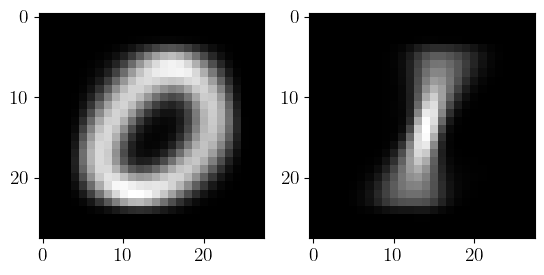

In [2]:
# plot the sample average images

import keras
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
index_0=np.where(y_train==0)[0]
index_1=np.where(y_train == 1)[0]
foreground=np.zeros(shape = (10000,28,28))
foreground[:2500,:,:]=X_train[index_0][:2500]
foreground[2500:5000,:,:]=X_train[index_1][:2500]
average_0 = np.average(X_train[index_0][:5000,:,:],axis = 0)
average_1 = np.average(X_train[index_1][:5000,:,:],axis = 0)
plt.subplot(1,2,1)
plt.imshow(average_0,cmap='gray')
plt.subplot(1,2,2)
plt.imshow(average_1,cmap='gray')

In [3]:
X=np.load("./corrupted_mnist_grass_cloud/X_independent_0_1_clearer.npy")
Y=np.load("./corrupted_mnist_grass_cloud/Y_independent_0_1_clearer.npy")
label = np.load("./corrupted_mnist_grass_cloud/label_independent_0_1_clearer.npy")

pca=PCA(n_components=30)
pca.fit(np.vstack((X,Y)))
print(np.cumsum(pca.explained_variance_ratio_))

index_0=np.where(label==0)
index_1=np.where(label==1)
index_2=np.where(label==2)
index_3=np.where(label==3)
label=np.hstack((np.zeros(X[index_0].shape[0]),np.ones(X[index_1].shape[0])))
X_0=X[index_0]
X_1=X[index_1]
X_2=X[index_2]
X_3=X[index_3]
X=np.vstack((X[index_0],X[index_1],X[index_2],X[index_3]))
X_pca_0=pca.transform(X_0)
X_pca_1=pca.transform(X_1)
X_pca_2=pca.transform(X_2)
X_pca_3=pca.transform(X_3)
Y_pca=pca.transform(Y)
X_pca=pca.transform(X)

# k2_f,k4_f=cumulant_tensors(X_pca)
# k2_b,k4_b=cumulant_tensors(Y_pca)
# np.save('corrupted_mnist_grass_cloud/k2_b_independent_0_1_clearer',k2_b)
# np.save('corrupted_mnist_grass_cloud/k2_f_independent_0_1_clearer',k2_f)
# np.save('corrupted_mnist_grass_cloud/k4_b_independent_0_1_clearer',k4_b)
# np.save('corrupted_mnist_grass_cloud/k4_f_independent_0_1_clearer',k4_f)

[0.59090856 0.65019975 0.68587312 0.71963569 0.73570372 0.74928612
 0.76117664 0.7694356  0.77632251 0.78281253 0.78906733 0.79489875
 0.80057309 0.80536753 0.80987463 0.81372686 0.81750523 0.82106652
 0.82408633 0.82696568 0.82960107 0.83213565 0.83461726 0.83705784
 0.8394126  0.84171743 0.84391436 0.8458064  0.84767264 0.84945705]


In [13]:
k4_f=np.load('corrupted_mnist_grass_cloud/k4_f_independent_0_1_clearer.npy')
k4_b=np.load('corrupted_mnist_grass_cloud/k4_b_independent_0_1_clearer.npy')
k2_f=np.load('corrupted_mnist_grass_cloud/k2_f_independent_0_1_clearer.npy')
k2_b=np.load('corrupted_mnist_grass_cloud/k2_b_independent_0_1_clearer.npy')

figsize = (6,8)
def plot_graph_mnist01(directions,xlabel,ylabel,title,sil_score):
    fig,axs=plt.subplots(1,1, figsize = figsize)
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@X_pca_0.T,pattern_2@X_pca_0.T,label='digit 0')
    axs.scatter(pattern_1@X_pca_1.T,pattern_2@X_pca_1.T,label='digit 1')
    axs.legend()
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')



def mnist_silhouette(directions):
    pattern_1=directions[:,0]
    pattern_2=directions[:,1]
    cluster_1=np.vstack((pattern_1@X_pca_0.T,pattern_2@X_pca_0.T))
    cluster_2=np.vstack((pattern_1@X_pca_1.T,pattern_2@X_pca_1.T))
    cluster_label=np.hstack((np.zeros(cluster_1.shape[1]),np.ones(cluster_2.shape[1])))
    cluster=np.hstack((cluster_1,cluster_2))
    return silhouette_score(cluster.T,cluster_label)

def plot_graph_mnist01_wholedataset(directions,xlabel,ylabel,title,sil_score):
    fig,axs=plt.subplots(1,1,figsize=figsize)
    pattern_1=directions[:,0].reshape(1,-1)
    pattern_2=directions[:,1].reshape(1,-1)
    axs.scatter(pattern_1@X_0.T,pattern_2@X_0.T,label='digit 0')
    axs.scatter(pattern_1@X_1.T,pattern_2@X_1.T,label='digit 1')
    axs.legend()
    axs.set_xlabel(xlabel)
    axs.set_ylabel(ylabel)
    axs.set_title(title+' '+'silhouette score:'+f'{sil_score:0.3f}')




def mnist_silhouette_wholedataset(directions):
    pattern_1=directions[:,0]
    pattern_2=directions[:,1]
    cluster_1=np.vstack((pattern_1@X_0.T,pattern_2@X_0.T))
    cluster_2=np.vstack((pattern_1@X_1.T,pattern_2@X_1.T))
    cluster_label=np.hstack((np.zeros(cluster_1.shape[1]),np.ones(cluster_2.shape[1])))
    cluster=np.hstack((cluster_1,cluster_2))
    return silhouette_score(cluster.T,cluster_label)



def patternimage_cICA(full_size_pattern):
    range = (full_size_pattern.max()-full_size_pattern.min())
    image = (full_size_pattern-full_size_pattern.min()).reshape(28,28)/range
    return image

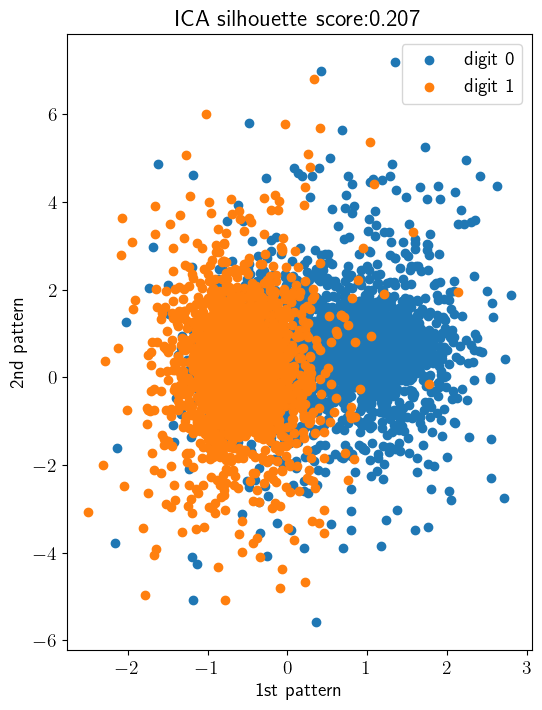

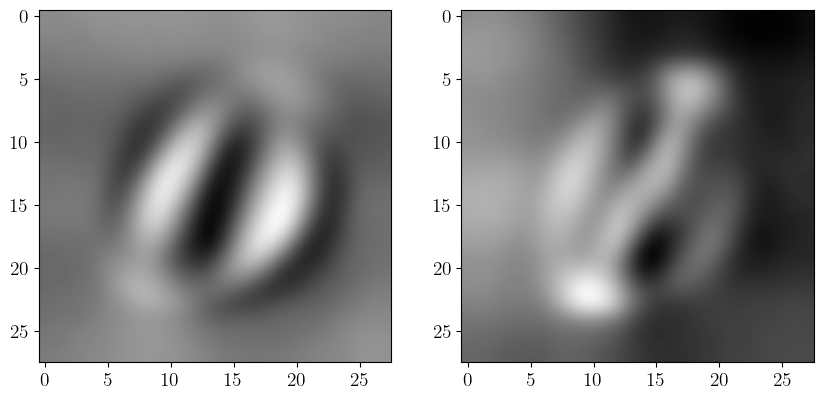

In [14]:
# ICA

np.random.seed(0)
a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=1,r=0,l=192)
# visualize the top2 patterns as images 
plot_graph_mnist01(b_s_sorted[:,:2],'1st pattern','2nd pattern','ICA',mnist_silhouette(b_s_sorted[:,:2]))

#plot data against top 2 ICA patterns
full_size_pattern = b_s_sorted.T@pca.components_
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(patternimage_cICA(full_size_pattern[0,:]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(full_size_pattern[1,:]), cmap="gray", interpolation="bicubic")

Text(0.5, 0, 'n-th eigenvalue')

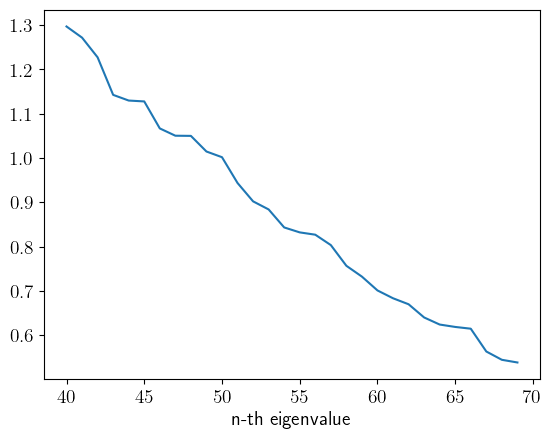

In [8]:
#cICA choices of r
I=k4_b.shape[0]
D,V=eig2(k4_b.reshape(I**2,I**2))
plt.figure()
plt.plot(range(40,70),abs(D)[40:70])
plt.xlabel('n-th eigenvalue')

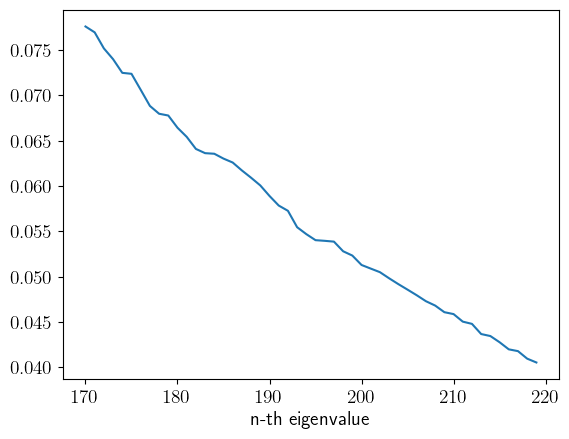

In [ ]:
#cICA choices of r+ell
I=k4_f.shape[0]
D,V=eig2(k4_b.reshape(I**2,I**2))
plt.figure()
plt.plot(range(170,220),abs(D)[170:220])
plt.xlabel('n-th eigenvalue')

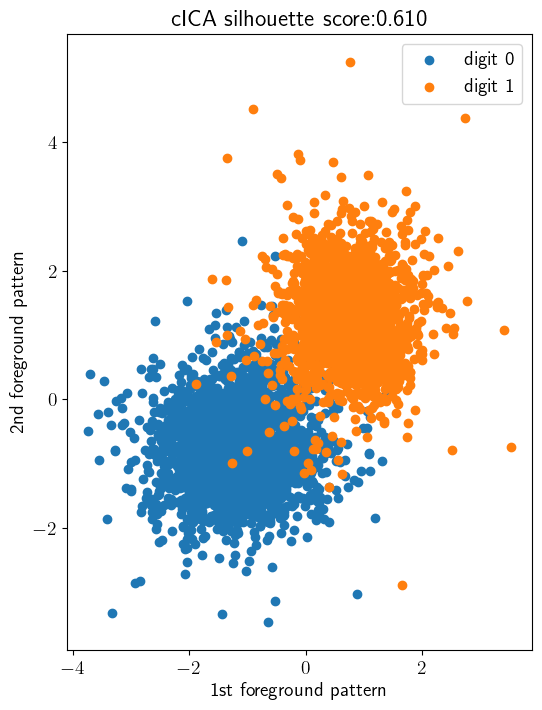

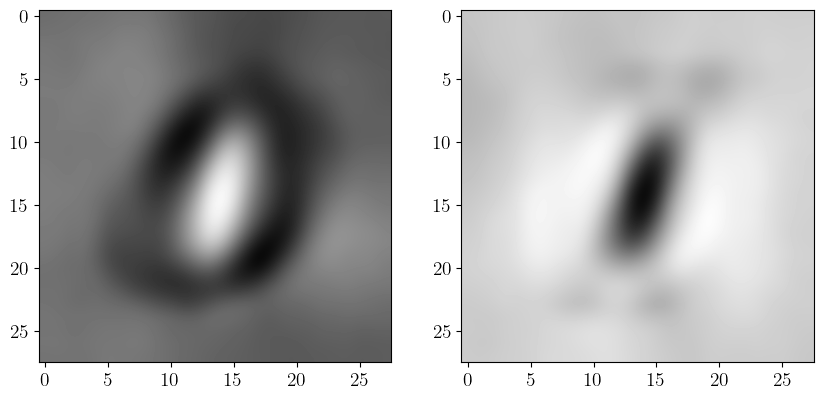

In [ ]:
#cICA
a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=1,r=51,l=192-51)

# visualization data projected to the top2 cICA directions
plot_graph_mnist01(b_s_sorted[:,:2],'1st foreground pattern','2nd foreground pattern','cICA',mnist_silhouette(b_s_sorted[:,:2]))

#cICA image
full_size_pattern = b_s_sorted.T@pca.components_
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(patternimage_cICA(full_size_pattern[0,:]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(-full_size_pattern[1,:]), cmap="gray", interpolation="bicubic")

In [ ]:
# evaluate the classification error rate on the first cICA direction
array_1 = b_s_sorted[:,0]@ X_pca[:2500,:].T
array_2 = b_s_sorted[:,0]@ X_pca[2500:5000,:].T
(np.sum(array_1<0)+np.sum(array_2>0))/5000

0.94

In [ ]:
# evaluate the classification error rate on the first cICA direction
array_1 = b_s_sorted[:,1]@ X_pca[:2500,:].T
array_2 = b_s_sorted[:,1]@ X_pca[2500:5000,:].T
(np.sum(array_1<0)+np.sum(array_2>0))/5000

0.9306

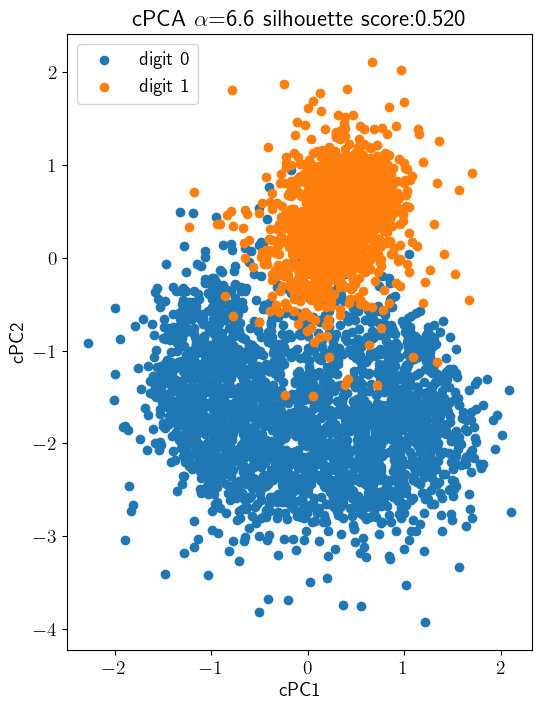

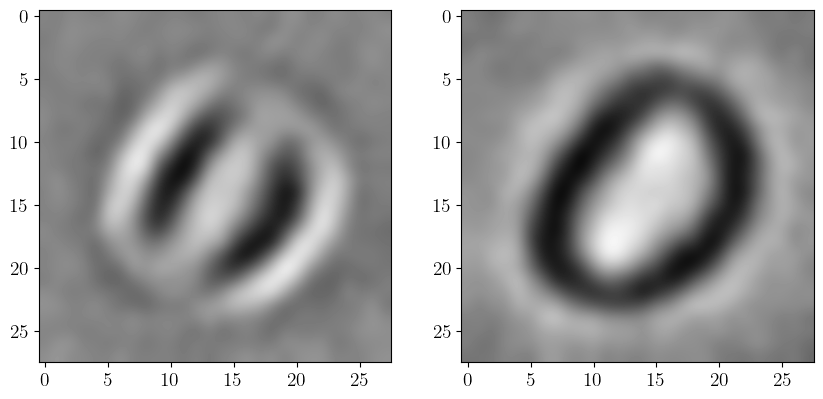

In [ ]:
#CPCA whole dataset
mdl=CPCA()
silhouette_score_list=[]
l,alphas=mdl.fit_transform(X,Y,n_alphas=100,return_alphas=True,max_log_alpha=3)
for array in l:
    silhouette_score_list.append(silhouette_score(array[:5000,:],label[:5000]))
index=np.argmax(np.array(silhouette_score_list))
alpha=alphas[index]

D,V=np.linalg.eig(mdl.fg_cov-alpha*mdl.bg_cov)
eig_idx = np.argpartition(D, -2)[-2:]
b_cpca=V[:,eig_idx]
plot_graph_mnist01_wholedataset(b_cpca,'cPC1','cPC2',f'cPCA $\\alpha$={alpha:0.1f}',silhouette_score_list[index])
directions=b_cpca
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(patternimage_cICA(b_cpca[:,0]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(b_cpca[:,1]), cmap="gray", interpolation="bicubic")

In [ ]:
# evaluate the classification error rate on the first cPCA direction
array_1 = b_cpca[:,0]@ X[:2500,:].T
array_2 = b_cpca[:,0]@ X[2500:5000,:].T
max((np.sum(array_1<0)+np.sum(array_2>0))/5000, 1-(np.sum(array_1<0)+np.sum(array_2>0))/5000)

0.7106

In [ ]:
# evaluate the classification error rate on the first cPCA direction
array_1 = b_cpca[:,1]@ X[:2500,:].T
array_2 = b_cpca[:,1]@ X[2500:5000,:].T
max((np.sum(array_1<0)+np.sum(array_2>0))/5000, 1-(np.sum(array_1<0)+np.sum(array_2>0))/5000)

0.9442

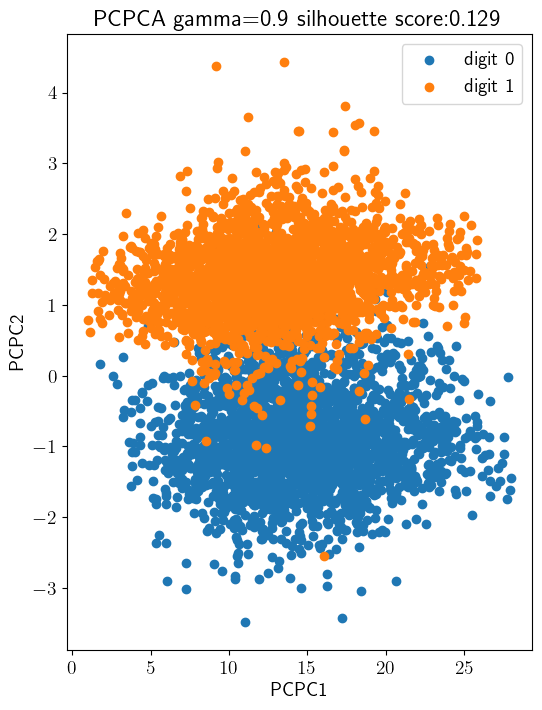

In [17]:
# PCPCA on whole dataset choose gamma
silhouette_score_list=[]
b_list=[]
n, m = X.shape[0], Y.shape[0]
for gamma in np.linspace(0,0.9,100):
    pcpca = PCPCA(gamma=n/m*gamma, n_components=2)
    X_reduced,Y_reduced=pcpca.fit_transform(X.T,Y.T)
    b=pcpca.W_mle
    # b=pcpca.W_mle/np.linalg.norm(pcpca.W_mle,axis=0,keepdims=True)
    silhouette_score_list.append(mnist_silhouette_wholedataset(b))
    b_list.append(b)
index=np.argmax(np.array(silhouette_score_list))
gamma=np.linspace(0,0.9,100)[index]

b=pcpca.W_mle/np.linalg.norm(pcpca.W_mle,axis=0,keepdims=True)
plot_graph_mnist01_wholedataset(b[:,[0,1]],'PCPC1','PCPC2',f'PCPCA gamma={gamma}',mnist_silhouette_wholedataset(b[:,[0,1]]))

In [ ]:
# evaluate the classification error rate on the first PCPCA direction
array_1 = b[:,0]@ X[:2500,:].T
array_2 = b[:,0]@ X[2500:5000,:].T
max((np.sum(array_1<0)+np.sum(array_2>0))/5000, 1-(np.sum(array_1<0)+np.sum(array_2>0))/5000)

0.5

In [ ]:
# evaluate the classification error rate on the first PCPCA direction
array_1 = b[:,1]@ X[:2500,:].T
array_2 = b[:,1]@ X[2500:5000,:].T
max((np.sum(array_1<0)+np.sum(array_2>0))/5000, 1-(np.sum(array_1<0)+np.sum(array_2>0))/5000)

0.9398

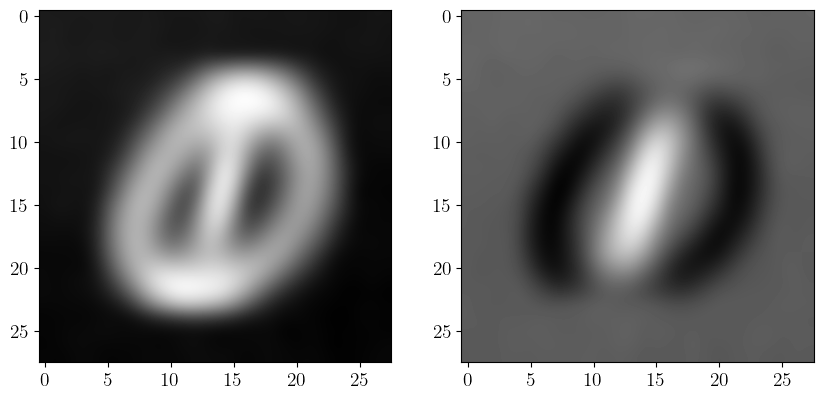

In [110]:
#PCPCA image
pattern = pcpca.W_mle
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(patternimage_cICA(pattern[:,0]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(pattern[:,1]), cmap="gray", interpolation="bicubic")

## MNIST continuous strength

In [ ]:
# # background 50% grass, 50% cloud, foreground 80% grass, 20% cloud
# # grass images are downloaded from imagenet with id n12102133
## cloud images are downloaded from imagenet with id n09247410


# grass_IMAGE_PATH = 'n12102133/' #Replace with your own path to downloaded images
# cloud_IMAGE_PATH = 'n09247410/' #Replace with your own path to downloaded images
# import keras
# from keras.datasets import mnist
# np.random.seed(0)
# (X_train, y_train), (X_test, y_test) = mnist.load_data()
# index_0=np.random.choice(list(np.where(y_train==0)[0]),10000,replace = True)
# index_1=np.random.choice(list(np.where(y_train == 1)[0]),10000, replace = True)
# strength = np.random.uniform(0,1,(2,10000))
# foreground=np.zeros(shape = (10000,28,28))
# for i in range(10000):
#     foreground[i,:]=(X_train[index_0[i]]*strength[0,i]+X_train[index_1[i]]*strength[1,i])/255



# from PIL import Image
# from resizeimage import resizeimage
# import os
        
# grass_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
# num=0
# for filename in os.listdir(grass_IMAGE_PATH):
#     num+=1
#     if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
#         try:
#             im = Image.open(os.path.join(grass_IMAGE_PATH,filename))
#             im = im.convert(mode="L") #convert to grayscale

#             im = resizeimage.resize_crop(im,[100,100]) #resize and crop each picture to be 100px by 100px
#             grass_images.append(np.reshape(im, [10000])) 
#         except Exception as e:
#             pass #print(e)
            
# grass_images=np.asarray(grass_images,dtype=float)
# grass_images/=255 #rescale to be 0-1
# print("Array of grass images:",grass_images.shape)


# cloud_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
# num=0
# for filename in os.listdir(cloud_IMAGE_PATH):
#     num+=1
#     if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
#         try:
#             im = Image.open(os.path.join(cloud_IMAGE_PATH,filename))
#             im = im.convert(mode="L") #convert to grayscale

#             im = resizeimage.resize_crop(im,[100,100]) #resize and crop each picture to be 100px by 100px
#             cloud_images.append(np.reshape(im, [10000])) 
#         except Exception as e:
#             pass #print(e)
    
# cloud_images=np.asarray(cloud_images,dtype=float)
# cloud_images/=255 #rescale to be 0-1
# print("Array of cloud images:",cloud_images.shape)
# # Corrupt the MNIST digits with the grass and cloud images 
# from tqdm import tqdm

# np.random.seed(0)  # for reproducibility

# grass_rand_indices = np.random.permutation(
#     grass_images.shape[0]
# )  # just shuffles the indices
# grass_split = int(len(grass_rand_indices) / 2)
# target_grass_indices = grass_rand_indices[
#     0:grass_split
# ]  # choose the first half of images to be superimposed on target
# background_grass_indices = grass_rand_indices[
#     grass_split:
# ]  # choose the second half of images to be background dataset



# cloud_rand_indices = np.random.permutation(
#     cloud_images.shape[0]
# )  # just shuffles the indices
# cloud_split = int(len(cloud_rand_indices) / 2)
# target_cloud_indices = cloud_rand_indices[
#     0:cloud_split
# ]  # choose the first half of images to be superimposed on target
# background_cloud_indices = cloud_rand_indices[
#     cloud_split:
# ]  # choose the second half of images to be background dataset

# target = np.zeros((foreground.shape[0],28**2))
# background = np.zeros((foreground.shape[0],28**2))


# permuted_index = np.random.permutation(10000)
# print("Corrupting MNIST with grass and cloud...")
# grass_cloud_foreground = np.zeros((foreground.shape[0],28**2))
# for i in range(int(target.shape[0]/10*8)):
#     idx = np.random.choice(target_grass_indices) # randomly pick a image 
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     superimposed_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784]) 
#     grass_cloud_foreground[i]=superimposed_patch
#     # foregroundreshaped=foreground[i].reshape(1,-1)
#     # target[permuted_index[i]] = 0.25* foregroundreshaped/255+ superimposed_patch

# for i in range(int(target.shape[0]/10*8),target.shape[0]):
#     idx = np.random.choice(target_cloud_indices) # randomly pick a image
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     superimposed_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
#     grass_cloud_foreground[i]=superimposed_patch
#     # foregroundreshaped=foreground[i].reshape(1,-1)
#     # target[permuted_index[i]] = 0.25* foregroundreshaped/255+ superimposed_patch

# for i in range(10000):
#     foregroundreshaped=foreground[i].reshape(1,-1)
#     target[i] = foregroundreshaped+ grass_cloud_foreground[permuted_index[i]]

# for i in range(target.shape[0]//2):
#     idx = np.random.choice(background_grass_indices) # randomly pick a image 
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     background_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])    
#     background[permuted_index[i]] = background_patch

#     idx = np.random.choice(background_cloud_indices) # randomly pick a image
#     loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
#     background_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
#     background[permuted_index[i+target.shape[0]//2]] = background_patch



# np.save("./mixed_MNIST_continuous/X.npy", target)
# np.save("./mixed_MNIST_continuous/Y.npy", background)

Array of grass images: (1269, 10000)
Array of cloud images: (1399, 10000)
Corrupting MNIST with grass and cloud...


[2732 9845 3264 4859]
[9225 7891 4373 5874]


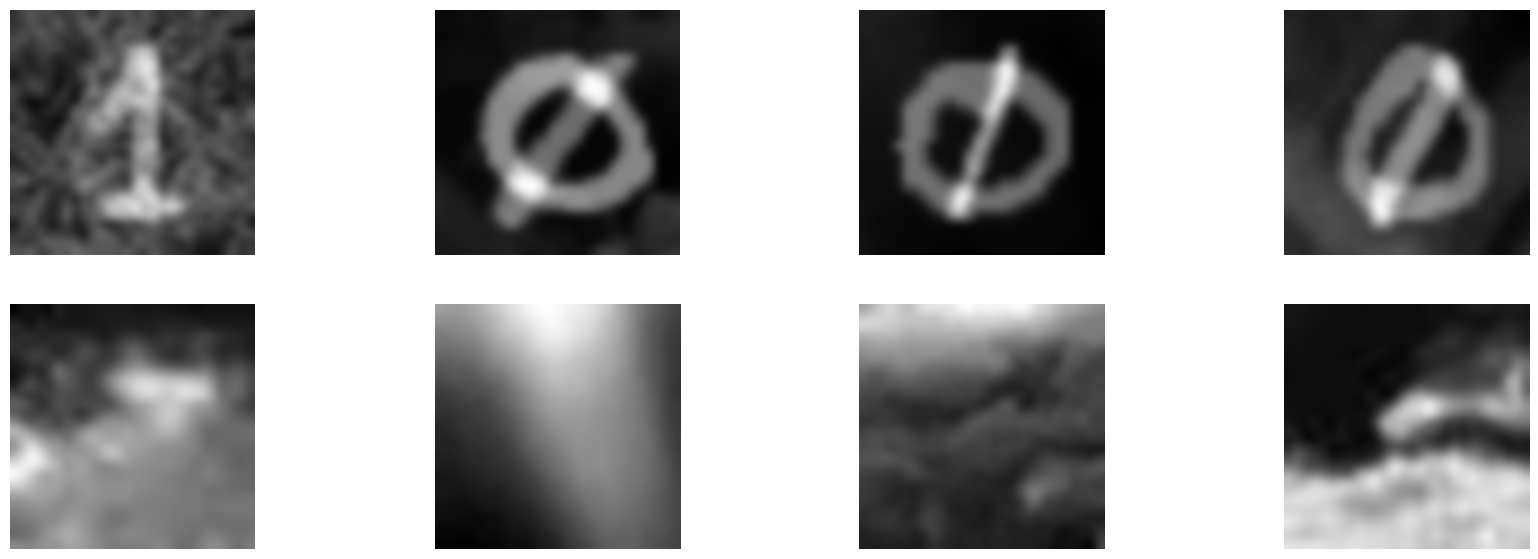

In [18]:
X=np.load("./mixed_MNIST_continuous/X.npy")
Y=np.load("./mixed_MNIST_continuous/Y.npy")
n_show = 4

plt.figure(figsize=[21, 7])
idx = np.random.choice(range(10000),4)
print(idx)
for i in range(n_show):
    plt.subplot(2, n_show, i + 1)
    plt.imshow(
        np.reshape(X[idx[i], :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")

idx = np.random.choice(range(10000),4)
print(idx)
for i in range(n_show):
    plt.subplot(2, n_show, n_show + i + 1)
    plt.imshow(
        np.reshape(Y[idx[i], :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")
plt.show()


In [27]:
pca=PCA(n_components=30)
X_centered = X-np.mean(X,axis=0,keepdims=True)
Y_centered = Y-np.mean(Y,axis=0,keepdims=True)
pca.fit(np.vstack((X,Y)))
print(np.cumsum(pca.explained_variance_ratio_))
Y_pca=pca.transform(Y_centered)
X_pca=pca.transform(X_centered)


# k2_f,k4_f=cumulant_tensors(X_pca)
# k2_b,k4_b=cumulant_tensors(Y_pca)
# np.save('mixed_MNIST_continuous/k2_b',k2_b)
# np.save('mixed_MNIST_continuous/k2_f',k2_f)
# np.save('mixed_MNIST_continuous/k4_b',k4_b)
# np.save('mixed_MNIST_continuous/k4_f',k4_f)

k4_f=np.load('mixed_MNIST_continuous/k4_f.npy')
k4_b=np.load('mixed_MNIST_continuous/k4_b.npy')
k2_f=np.load('mixed_MNIST_continuous/k2_f.npy')
k2_b=np.load('mixed_MNIST_continuous/k2_b.npy')

[0.47491477 0.58192339 0.62332007 0.6510176  0.67588209 0.69804601
 0.71772756 0.73380596 0.74730012 0.7561417  0.76401646 0.77146232
 0.77777041 0.78369109 0.7894887  0.79456541 0.79958979 0.80445757
 0.80900659 0.81351239 0.81748075 0.82116058 0.82465089 0.82807985
 0.83145126 0.8344241  0.83727453 0.83999166 0.84263211 0.8451236 ]


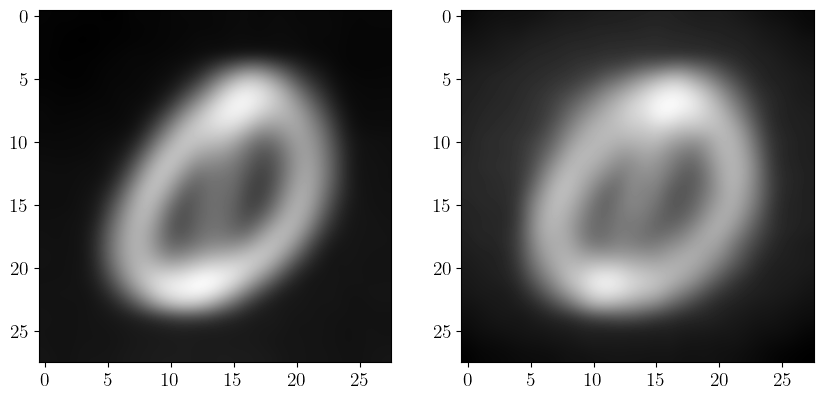

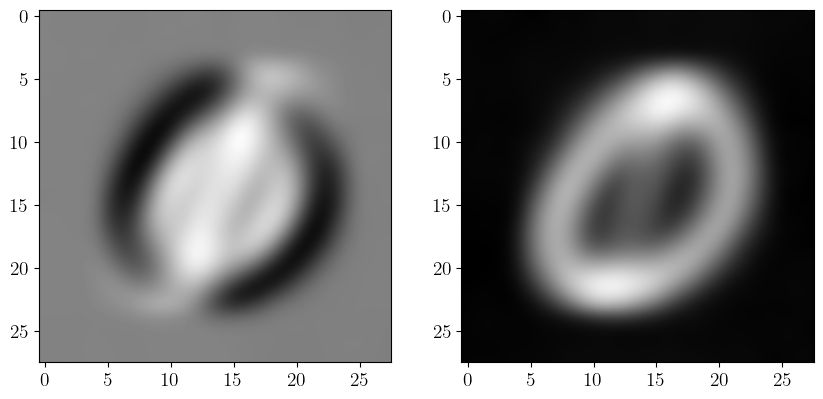

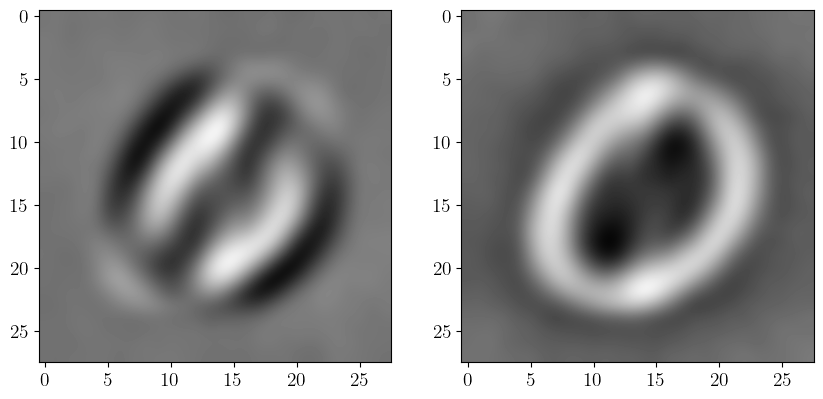

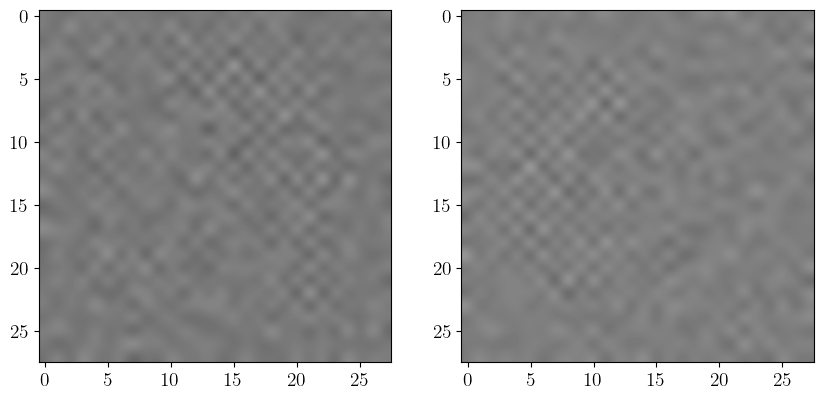

In [20]:
# cPCA 
mdl=CPCA()
l,alphas=mdl.fit_transform(X,Y,return_alphas=True,n_alphas_to_return=4)
k2_full_f = np.cov(X.T)
k2_full_b = np.cov(Y.T)
for alpha in alphas:
    D,V=np.linalg.eig(k2_full_f-alpha*k2_full_b)
    eig_idx = np.argpartition(D, -2)[-2:]
    b_cpca=V[:,eig_idx]
    full_size_pattern = b_cpca
    fig,axes = plt.subplots(1,2,figsize=(10,5))
    axes[0].imshow(patternimage_cICA(full_size_pattern[:,0]), cmap="gray", interpolation="bicubic")
    axes[1].imshow(patternimage_cICA(full_size_pattern[:,1]), cmap="gray", interpolation="bicubic")


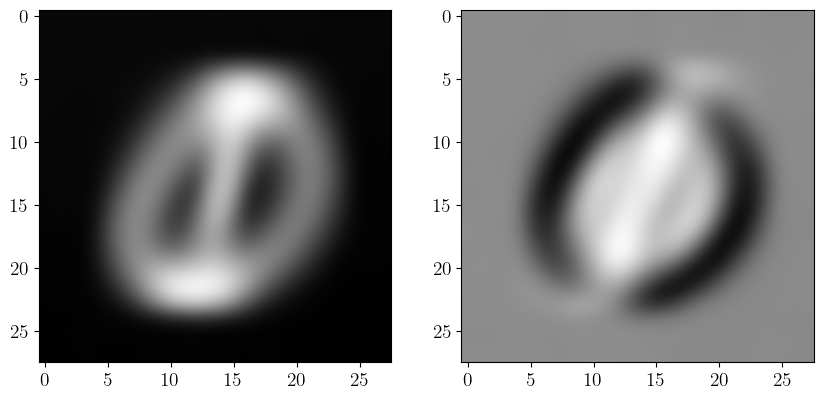

In [51]:
# PCPCA
#PCPCA with gamma = 0.9
gamma = 0.9
n,m=X.shape[0],Y.shape[0]
pcpca = PCPCA(gamma=n/m*gamma, n_components=2)
pcpca.fit(X.T,Y.T)
b=pcpca.W_mle/np.linalg.norm(pcpca.W_mle,axis=0,keepdims=True)
full_size_pattern = b
fig,axes = plt.subplots(1,2,figsize=(10,5))
axes[0].imshow(patternimage_cICA(full_size_pattern[:,0]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(full_size_pattern[:,1]), cmap="gray", interpolation="bicubic")

Text(0.5, 0, 'n-th eigenvalue')

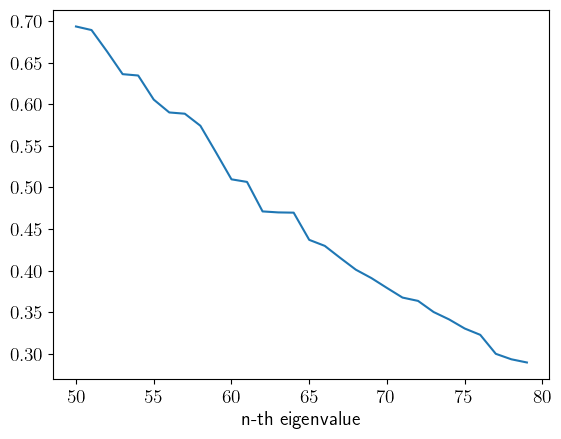

In [22]:
# choice of r for cICA
I=k4_b.shape[0]
D,V=eig2(k4_b.reshape(I**2,I**2))
plt.figure()
plt.plot(range(50,80),abs(D)[50:80])
plt.xlabel('n-th eigenvalue')


Text(0.5, 0, 'n-th eigenvalue')

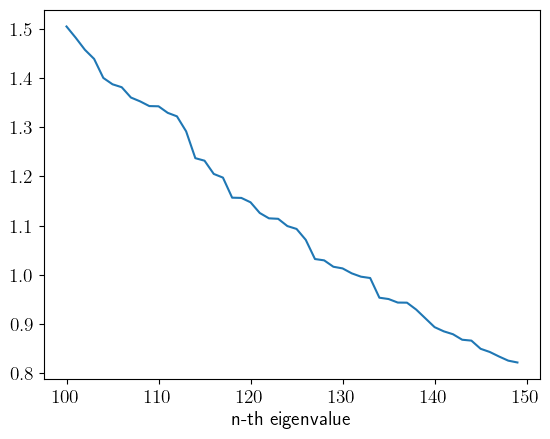

In [21]:
# choice of r+l for cICA
I=k4_f.shape[0]
D,V=eig2(k4_f.reshape(I**2,I**2))
plt.figure()
plt.plot(range(100,150),abs(D)[100:150])
plt.xlabel('n-th eigenvalue')


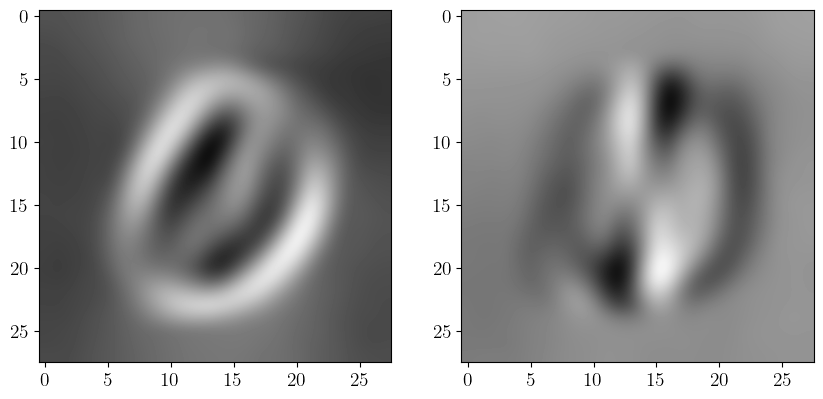

In [28]:
#cICA image
np.random.seed(0)
a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=1,r=65,l=65)

full_size_pattern = b_s_sorted.T@pca.components_
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(-patternimage_cICA(full_size_pattern[0,:]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(-full_size_pattern[1,:]), cmap="gray", interpolation="bicubic")

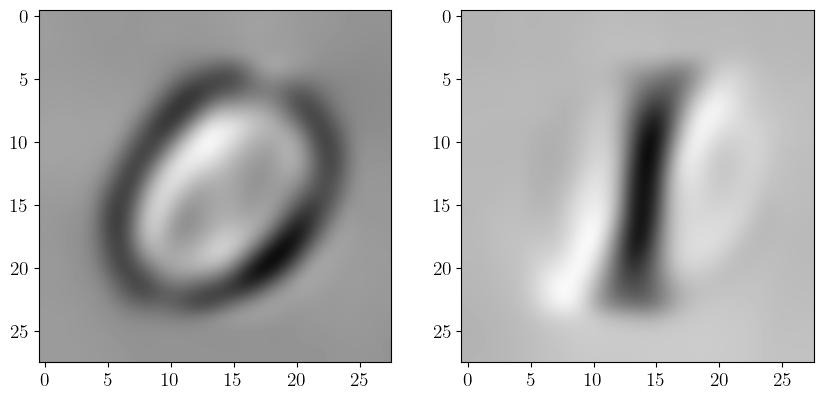

In [ ]:
#cICA image
np.random.seed(0)
a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=1,r=65,l=65)

full_size_pattern = b_s_sorted.T@pca.components_
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(-patternimage_cICA(full_size_pattern[0,:]), cmap="gray", interpolation="bicubic")
axes[1].imshow(patternimage_cICA(-full_size_pattern[1,:]), cmap="gray", interpolation="bicubic")

# Interpretablity

## non-proportional setting

In [70]:
np.random.seed()
cICA_cosine_list=[]
cICA_rel_frob_list=[]
CPCA_cosine_list=[]
CPCA_rel_frob_list=[]
pcpca_cosine_list=[]
pcpca_rel_frob_list=[]
HTD_cosine_list=[]
HTD_rel_frob_list=[]

for n in range(4,13):
    matrix=np.random.rand(n,n)
    Q,r=np.linalg.qr(matrix)
    B=Q[:,1:]
    A=np.random.randn(n,n)
    A=A/np.linalg.norm(A,axis=0)
    scale=[2,1]*n
    scale_2=[1,2]*n
    n_samples=100000
    y=np.zeros((n-1,n_samples))
    scale_3=[2,1.5]*n
    for i in range(n-1):
        y[i,:]=np.random.exponential(scale_3[i],size=n_samples)
    x_1=np.zeros((n,n_samples))
    x_2=np.zeros((n,n_samples))
    for i in range(n):
        x_1[i,:]=np.random.exponential(scale=scale[i],size=n_samples)
        x_2[i,:]=np.random.exponential(scale=scale_2[i],size=n_samples)
    X=A@x_2+B@y
    Y=A@x_1
    k2_f,k4_f=cumulant_tensors(X.T)
    k2_b,k4_b=cumulant_tensors(Y.T)
    
    cosine_list=[]
    rel_frob_list=[]
    # cICA on synthetic data
    for i in range(100):
            a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=30,r=n,l=n-1)
            cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_s_sorted,B)
            cosine_list.append(cosine_sim_list)
            rel_frob_list.append(relfroberror)
    cICA_cosine_list.append(cosine_list)
    cICA_rel_frob_list.append(rel_frob_list)

    pcpca_cosine_list_l = []
    pcpca_rel_frob_list_l = []
    # PCPCA on synthetic data
    for i,gamma in enumerate(np.linspace(0,0.9,100)):
            pcpca = PCPCA(gamma=gamma, n_components=n-1)
            pcpca.fit(X,Y)
            pcpca_B=pcpca.W_mle
            pcpca_B=pcpca_B/np.linalg.norm(pcpca_B,axis=0)
            cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(pcpca_B,B)
            pcpca_cosine_list_l.append(cosine_sim_list)
            pcpca_rel_frob_list_l.append(relfroberror)
    pcpca_cosine_list.append(pcpca_cosine_list_l)
    pcpca_rel_frob_list.append(pcpca_rel_frob_list_l)

    
    alphas=np.logspace(-4,4,num=100)
    # CPCA on synthetic data
    CPCA_cosine_list_l = []
    CPCA_rel_frob_list_l = []
    for alpha in alphas:
        D,V=eig2(k2_f-alpha*k2_b)
        b_cpca=V[:,:n-1]
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_cpca,B)
        CPCA_cosine_list_l.append(cosine_sim_list)
        CPCA_rel_frob_list_l.append(relfroberror)
    CPCA_cosine_list.append(CPCA_cosine_list_l)
    CPCA_rel_frob_list.append(CPCA_rel_frob_list_l)


    # HTD on synthetic data 
    HTD_cosine_list_l = []
    HTD_rel_frob_list_l = []
    for alpha in alphas: 
        gamma=np.sqrt(alpha)
        b_s_sorted,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,n-1)
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_s_sorted,B)
        HTD_cosine_list.append(cosine_sim_list)
        HTD_rel_frob_list.append(relfroberror)
    HTD_cosine_list.append(HTD_cosine_list_l)
    HTD_rel_frob_list.append(HTD_rel_frob_list_l)


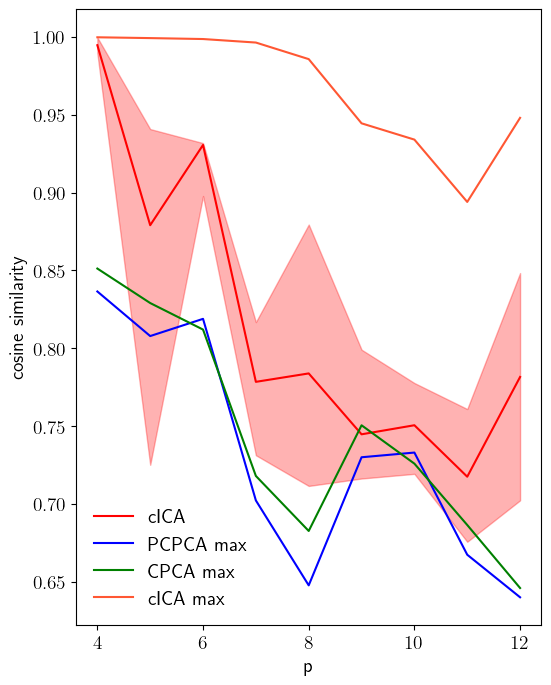

In [71]:
CICA_75=[]
CICA_median=[]
CICA_25=[]
CICA_max=[]
CPCA_75=[]
CPCA_median=[]
CPCA_25=[]
HTD_75=[]   
HTD_median=[]
HTD_25=[]
PCPCA_75=[]
PCPCA_median=[]
PCPCA_25=[]
PCPCA_max=[]
CPCA_max=[]
HTD_max=[]
for n in range(4,13):
    a = [np.mean(x) for x in pcpca_cosine_list[n-4]]
    b = np.mean(cICA_cosine_list[n-4],axis=1)
    c = [np.mean(x) for x in CPCA_cosine_list[n-4]]
    d = [np.mean(x) for x in HTD_cosine_list[n-4]]
    PCPCA_75.append(np.quantile(a,0.75))
    PCPCA_median.append(np.median(a))
    PCPCA_25.append(np.quantile(a,0.25))
    PCPCA_max.append(np.max(a))

    CICA_75.append(np.quantile(b,0.75))
    CICA_median.append(np.median(b))
    CICA_25.append(np.quantile(b,0.25))
    CICA_max.append(np.max(b))

    CPCA_75.append(np.quantile(c,0.75))
    CPCA_median.append(np.median(c))
    CPCA_25.append(np.quantile(c,0.25))
    CPCA_max.append(np.max(c))

    HTD_75.append(np.quantile(d,0.75))
    HTD_median.append(np.median(d))
    HTD_25.append(np.quantile(d,0.25))
    HTD_max.append(np.max(d))
    
fix,ax=plt.subplots(1,1,figsize=(6,8))
ax.plot(range(4,13),CICA_median,label='cICA',color='red')
ax.fill_between(range(4,13), CICA_25, CICA_75, color='red', alpha=0.3)

ax.plot(range(4,13),PCPCA_max,label='PCPCA max',color='blue')

ax.plot(range(4,13),CPCA_max,label='CPCA max',color='green')

ax.plot(range(4,13),CICA_max,label='cICA max',color='#FF5733')

ax.set_xlabel('p')
ax.set_ylabel('cosine similarity')
ax.legend(frameon=False)


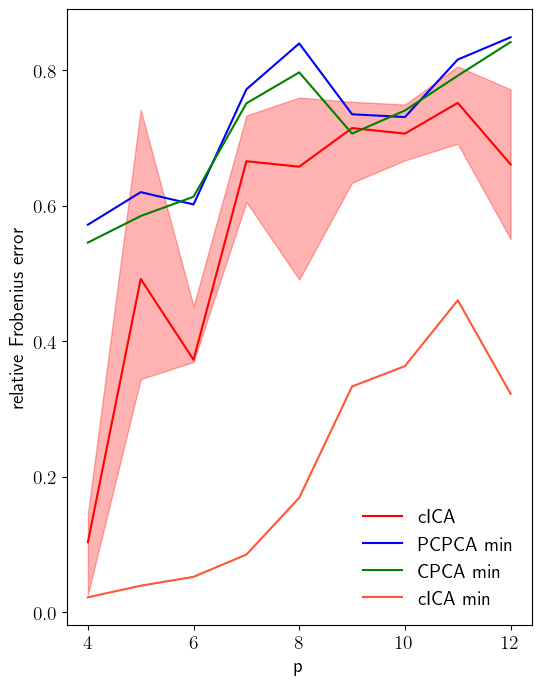

In [72]:
CICA_75=[]
CICA_median=[]
CICA_25=[]
CICA_min=[]
CPCA_75=[]
CPCA_median=[]
CPCA_25=[]
HTD_75=[]   
HTD_median=[]
HTD_25=[]
PCPCA_75=[]
PCPCA_median=[]
PCPCA_25=[]
PCPCA_min=[]
CPCA_min=[]
HTD_min=[]
for n in range(4,13):
    a = pcpca_rel_frob_list[n-4]
    b = cICA_rel_frob_list[n-4]
    c = CPCA_rel_frob_list[n-4]
    d = HTD_rel_frob_list[n-4]
    PCPCA_75.append(np.quantile(a,0.75))
    PCPCA_median.append(np.median(a))
    PCPCA_25.append(np.quantile(a,0.25))
    PCPCA_min.append(np.min(a))

    CICA_75.append(np.quantile(b,0.75))
    CICA_median.append(np.median(b))
    CICA_25.append(np.quantile(b,0.25))
    CICA_min.append(np.min(b))

    CPCA_75.append(np.quantile(c,0.75))
    CPCA_median.append(np.median(c))
    CPCA_25.append(np.quantile(c,0.25))
    CPCA_min.append(np.min(c))

    HTD_75.append(np.quantile(d,0.75))
    HTD_median.append(np.median(d))
    HTD_25.append(np.quantile(d,0.25))
    HTD_min.append(np.min(d))

fix,ax=plt.subplots(1,1,figsize=(6,8))
ax.plot(range(4,13),CICA_median,label='cICA',color='red')
ax.fill_between(range(4,13), CICA_25, CICA_75, color='red', alpha=0.3)

ax.plot(range(4,13),PCPCA_min,label='PCPCA min',color='blue')

ax.plot(range(4,13),CPCA_min,label='CPCA min',color='green')

ax.plot(range(4,13),CICA_min,label='cICA min',color='#FF5733')

ax.set_xlabel('p')
ax.set_ylabel('relative Frobenius error')
ax.legend(frameon=False)

# proportional setting

In [66]:
best_gamma=[]
CPCA_cosine_list=[]
CPCA_rel_frob_list=[]
HTD_cosine_list=[]
HTD_rel_frob_list=[]
pcpca_cosine_list=[]
pcpca_rel_frob_list=[]
for n in range(4,13):
    matrix=np.random.rand(n,n)
    Q,r=np.linalg.qr(matrix)
    B=Q[:,1:]
    A=np.random.randn(n,n)
    A=A/np.linalg.norm(A,axis=0)
    n_samples=100000
    np.random.seed(0)
    y=np.zeros((n-1,n_samples))
    scale_3=[2,1.5]*n
    for i in range(n-1):
        y[i,:]=np.random.exponential(scale_3[i],size=n_samples)
    x_1=np.random.exponential(2,size=(n,n_samples))
    x_2=np.random.exponential(2,size=(n,n_samples))
    X=A@x_2+B@y
    Y=A@x_1
    k2_f,k4_f=cumulant_tensors(X.T)
    k2_b,k4_b=cumulant_tensors(Y.T)

    CPCA_cosine_list_l = []
    CPCA_rel_frob_list_l = []
    alphas=np.logspace(-4,4,num=100)
    for alpha in alphas:
        D,V=eig2(k2_f-alpha*k2_b)
        b_cpca=V[:,:n-1]
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_cpca,B)
        CPCA_cosine_list_l.append(cosine_sim_list)
        CPCA_rel_frob_list_l.append(relfroberror)
    cosine_array=np.array(CPCA_cosine_list_l)
    index=np.argmax(np.mean(cosine_array,axis = 1))
    CPCA_cosine_array=np.array(CPCA_cosine_list_l[index])
    CPCA_rel_frob_array=np.array(CPCA_rel_frob_list_l[index])
    CPCA_cosine_list.append(CPCA_cosine_array)
    CPCA_rel_frob_list.append(CPCA_rel_frob_array)
    
    cosine_sim_list_l = []
    relfroberror_l = []
    for alpha in alphas: 
        gamma=np.sqrt(alpha)
        b_s_sorted,coeff=HTD(k4_b,k4_f,k2_b,k2_f,gamma,n-1)
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_s_sorted,B)
        cosine_sim_list_l.append(cosine_sim_list)
        relfroberror_l.append(relfroberror)
    cosine_array=np.array(cosine_sim_list_l)
    index=np.argmax(np.mean(cosine_array,axis = 1))
    best_gamma.append(np.sqrt(alphas)[index])
    HTD_cosine_list.append(cosine_sim_list_l[index])
    HTD_rel_frob_list.append(relfroberror_l[index])

    pcpca_cosine_list_l = []
    pcpca_rel_frob_list_l = []

    for i,gamma in enumerate(np.linspace(0,0.9,100)):
            pcpca = PCPCA(gamma=gamma, n_components=n-1)
            pcpca.fit(X,Y)
            pcpca_B=pcpca.W_mle
            pcpca_B=pcpca_B/np.linalg.norm(pcpca_B,axis=0)
            cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(pcpca_B,B)
            pcpca_cosine_list_l.append(cosine_sim_list)
            pcpca_rel_frob_list_l.append(relfroberror)  
    cosine_array=np.array(pcpca_cosine_list_l)
    index=np.argmax(np.mean(cosine_array,axis = 1))
    pcpca_cosine_array=np.array(pcpca_cosine_list_l[index])
    pcpca_rel_frob_array=np.array(pcpca_rel_frob_list_l[index])
    pcpca_cosine_list.append(pcpca_cosine_array)
    pcpca_rel_frob_list.append(pcpca_rel_frob_array)


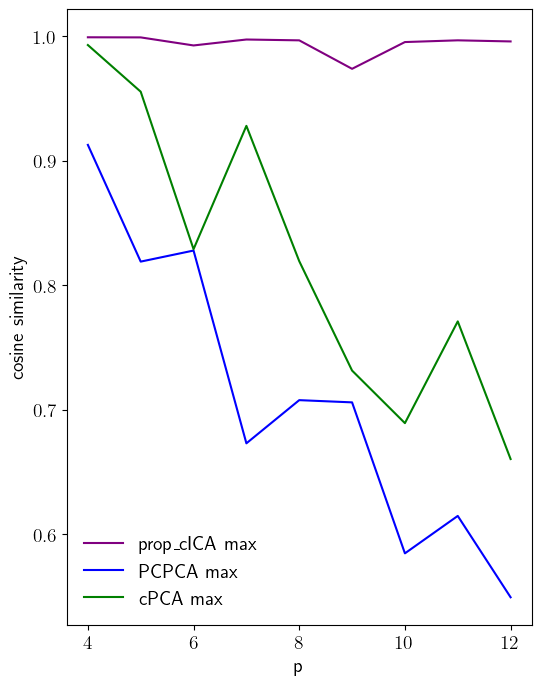

In [67]:
fix,ax=plt.subplots(1,1,figsize=(6,8))
ax.plot(range(4,13),[np.mean(x) for x in HTD_cosine_list],label='prop_cICA max',color='purple')

ax.plot(range(4,13),[np.mean(x) for x in pcpca_cosine_list],label='PCPCA max',color='blue')

ax.plot(range(4,13),[np.mean(x) for x in CPCA_cosine_list],label='cPCA max',color='green')

ax.set_xlabel('p')
ax.set_ylabel('cosine similarity')
ax.legend(frameon=False)

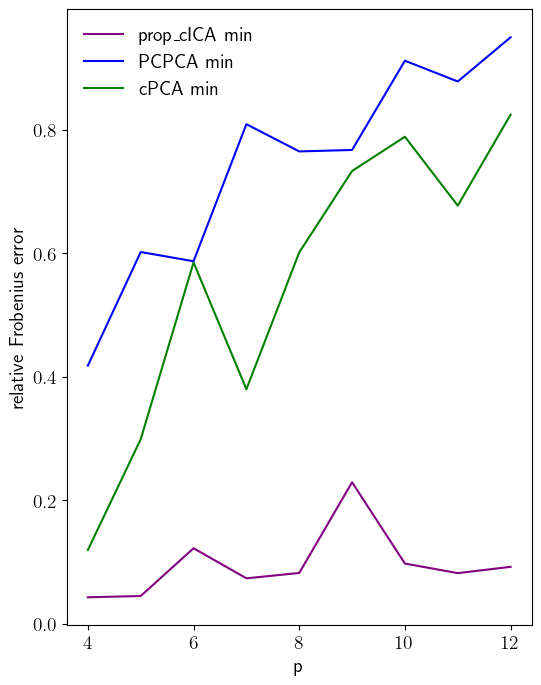

In [69]:
fix,ax=plt.subplots(1,1,figsize=(6,8))
ax.plot(range(4,13),[np.min(x) for x in HTD_rel_frob_list],label='prop_cICA min',color='purple')

ax.plot(range(4,13),[np.min(x) for x in pcpca_rel_frob_list],label='PCPCA min',color='blue')

ax.plot(range(4,13),[np.min(x) for x in CPCA_rel_frob_list],label='cPCA min',color='green')
ax.set_xlabel('p')
ax.set_ylabel('relative Frobenius error')
ax.legend(frameon=False)

# nonlinearity

In [20]:
n=4
matrix=np.random.rand(n,n)
Q,r=np.linalg.qr(matrix)
B=Q[:,0:2]
A=Q[:,2:]
n_samples=1000000


# do a nonlinear transformation of columns of x
def transform_columns(matrix):
    # Get the number of columns
    num_cols = matrix.shape[1]
    
    # Initialize an empty list to store the transformed columns
    transformed_columns = []
    
    # Iterate over each column
    for i in range(num_cols):
        x, y = matrix[:, i]
        transformed_column = [x**3, x**2 * y, x * y**2, y**3]
        transformed_columns.append(transformed_column)
    
    # Convert the list of transformed columns to a numpy array
    transformed_matrix = np.array(transformed_columns).T
    
    return transformed_matrix


y=np.zeros((n-2,n_samples))
scale_3=[2,1.5]*n
for i in range(n-2):
    y[i,:]=np.random.exponential(scale_3[i],size=n_samples)
x_1=np.random.exponential(2,size=(2,n_samples))
x_2=np.random.exponential(2,size=(2,n_samples))
alphas=[0,0.0001,0.001,0.01,0.1,1]


lambda_squared_list=np.logspace(-4,4,num=100)

#nonlinear perturbation on background, see how good cICA performs
cosine_mean_list_background=[]
rel_frob_list_mean_background=[]

np.random.seed()
for alpha in alphas:
    X=A@x_2+B@y + alpha*transform_columns(x_2)
    Y=A@x_1+alpha*transform_columns(x_1)
    k2_f,k4_f=cumulant_tensors(X.T)
    k2_b,k4_b=cumulant_tensors(Y.T)
    cosine_list=[]
    rel_frob_list=[]
    for i in range(100):
        a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=30,r=2,l=2)
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_s_sorted,B)
        cosine_list.append(cosine_sim_list)
        rel_frob_list.append(relfroberror)
    cosine_mean_list_background.append(np.mean(cosine_sim_list))
    rel_frob_list_mean_background.append(np.mean(relfroberror))

#nonlinear perturbation on just foreground 
cosine_mean_list_foreground=[]
rel_frob_list_mean_foreground=[]

np.random.seed()
for alpha in alphas:
    X=A@x_2+B@y+alpha*transform_columns(y)
    Y=A@x_1 
    k2_f,k4_f=cumulant_tensors(X.T)
    k2_b,k4_b=cumulant_tensors(Y.T)
    cosine_list=[]
    rel_frob_list=[]
    for i in range(100):
        a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=30,r=2,l=2)
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_s_sorted,B)
        cosine_list.append(cosine_sim_list)
        rel_frob_list.append(relfroberror)
    cosine_mean_list_foreground.append(np.mean(cosine_sim_list))
    rel_frob_list_mean_foreground.append(np.mean(relfroberror))


# nonlinear perturbation on both foreground and background
cosine_mean_list_both=[]
rel_frob_list_mean_both=[]

np.random.seed()

for alpha in alphas:
    X=A@x_2+B@y+alpha*transform_columns(y)+alpha*transform_columns(x_2)
    Y=A@x_1+alpha*transform_columns(x_1)
    k2_f,k4_f=cumulant_tensors(X.T)
    k2_b,k4_b=cumulant_tensors(Y.T)
    cosine_list=[]
    rel_frob_list=[]
    for i in range(50):
        a_s,b_s_sorted,_=recover_pattern_tensor_eigen(k4_b,k4_f,k2_f,k2_b,step_max=30,r=2,l=2)
        cosine_sim_list,mean_cosine_list,relfroberror,froberror=similarity_measures_withpermutation(b_s_sorted,B)
        cosine_list.append(cosine_sim_list)
        rel_frob_list.append(relfroberror)
    cosine_mean_list_both.append(np.mean(cosine_sim_list))
    rel_frob_list_mean_both.append(np.mean(relfroberror))


Text(0.5, 1.0, 'nonlinearity in background, foreground and both')

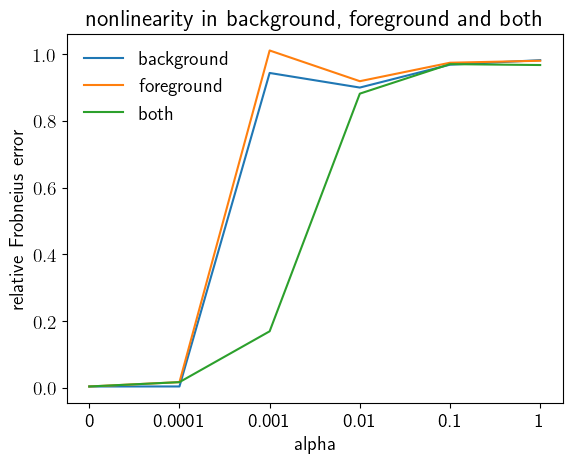

In [21]:
fix,ax=plt.subplots(1,1)
ax.plot(range(1,7),rel_frob_list_mean_background,label='background')
ax.plot(range(1,7),rel_frob_list_mean_foreground,label='foreground')
ax.plot(range(1,7),rel_frob_list_mean_both,label='both')

ax.set_xlabel('alpha')
ax.set_ylabel('relative Frobneius error')
ax.legend(frameon=False)
ax.set_xticks(range(1,7))
ax.set_xticklabels(alphas)
ax.set_title("nonlinearity in background, foreground and both")